# 🚗 Week 2 — End-to-End ML Pipeline on Tesla EV Sales & Price Data
**Name:** Ronak Sharma &nbsp;|&nbsp; **Program:** Celebal Technologies Data Science Internship  
**Dataset:** Tesla EA Deliveries & Production Data (2015–2025)  
**Kaggle:** https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025

---
### What this notebook covers (Week 2 Curriculum Checklist)
|  Topic |  Topic |
|---------|---------|
| Types of ML | Linear Regression |
| ML Pipeline (sklearn) | Ridge Regression (L2) |
| Bias-Variance Tradeoff | Lasso Regression (L1) |
| Overfitting & Underfitting | ElasticNet |
| Data Cleaning | Random Forest & Gradient Boosting |
| EDA (Univariate, Bivariate, Multivariate) | Evaluation Metrics (MAE, RMSE, R², MAPE) |
| Encoding (Label, One-Hot) | Cross-Validation (KFold + TimeSeriesSplit) |
| Feature Scaling (Standard, MinMax) | Hyperparameter Tuning (GridSearchCV, RandomizedSearchCV) |
| Feature Engineering | Time Series Components + Decomposition |
| Data Leakage (Prevention) | Stationarity (ADF Test) |
| Chronological Split | Lag Features + Rolling Statistics |
| Pipelines | Forecasting (Ridge + Holt-Winters) |

**Primary target:** `Estimated_Deliveries` (monthly sales volume — R² ≈ 0.98)  
**Secondary analysis:** `Avg_Price_USD` (pricing pattern analysis)


## 0. Setup — Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline

# Sklearn — preprocessing
from sklearn.preprocessing import (LabelEncoder, StandardScaler,
                                   MinMaxScaler, PolynomialFeatures)
# Sklearn — models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Sklearn — pipeline & selection
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, RandomizedSearchCV,
                                     KFold, TimeSeriesSplit, learning_curve)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Stats / Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.stats import randint as sp_randint

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.25, 'font.size': 11
})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All libraries loaded successfully.")


All libraries loaded successfully.


---
## Part 1 — Types of Machine Learning

Machine learning is broadly split into three categories based on how the algorithm learns:

| Type | How it works | This notebook uses |
|------|-------------|-------------------|
| **Supervised Learning** | Learns a mapping from labelled input-output pairs | ✅ All regression models here — delivery volume is the label |
| **Unsupervised Learning** | Finds structure in unlabelled data (clustering, dimensionality reduction) | Not used here |
| **Reinforcement Learning** | An agent learns by interacting with an environment and receiving rewards | Not used here |

Within supervised learning, we are solving a **regression** problem (predicting a continuous number — monthly delivery count) rather than classification (predicting a category).

**ML Pipeline** — the full workflow we follow:
```
Raw Data → Cleaning → EDA → Feature Engineering → Encoding → Scaling
         → Pipeline → Train/Val Split → Model Training
         → Hyperparameter Tuning → Cross-Validation → Evaluation → Forecasting
```


---
## Part 2 — Data Loading & Cleaning
### 2.1 Load Dataset

In [3]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape  : (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


### 2.2 Data Types & Statistical Summary

In [4]:
print(df.dtypes)
print()
df.describe().T.round(2)


Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object



,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.00,3.16,2015.00,2017.00,2020.00,2023.00,2025.00
Month,2640.0,6.50,3.45,1.00,3.75,6.50,9.25,12.00
Estimated_Deliveries,2640.0,9922.20,3935.95,48.00,7292.00,9857.00,12510.25,25704.00
Production_Units,2640.0,10655.85,4260.60,50.00,7828.25,10546.50,13469.00,28939.00
Avg_Price_USD,2640.0,84907.34,20123.26,50003.70,67726.36,85058.51,102373.04,119965.36
Battery_Capacity_kWh,2640.0,87.06,20.84,60.00,75.00,82.00,100.00,120.00
Range_km,2640.0,500.26,120.87,330.00,418.00,470.00,586.25,719.00
CO2_Saved_tons,2640.0,744.08,353.22,3.07,499.62,699.52,943.76,2548.55
Charging_Stations,2640.0,8932.13,3469.57,3002.00,5897.75,8901.50,11938.00,14996.00


### 2.3 Missing Value Analysis

In [5]:
miss = df.isnull().sum()
pct  = (miss / len(df) * 100).round(2)
report = pd.DataFrame({'Missing Count': miss, 'Missing %': pct})
print(report[miss > 0] if miss.sum() > 0 else "✅ No missing values found.")


✅ No missing values found.


### 2.4 Duplicate Check

In [6]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed. New shape: {df.shape}")


Duplicate rows: 0


### 2.5 Outlier Detection — IQR Method

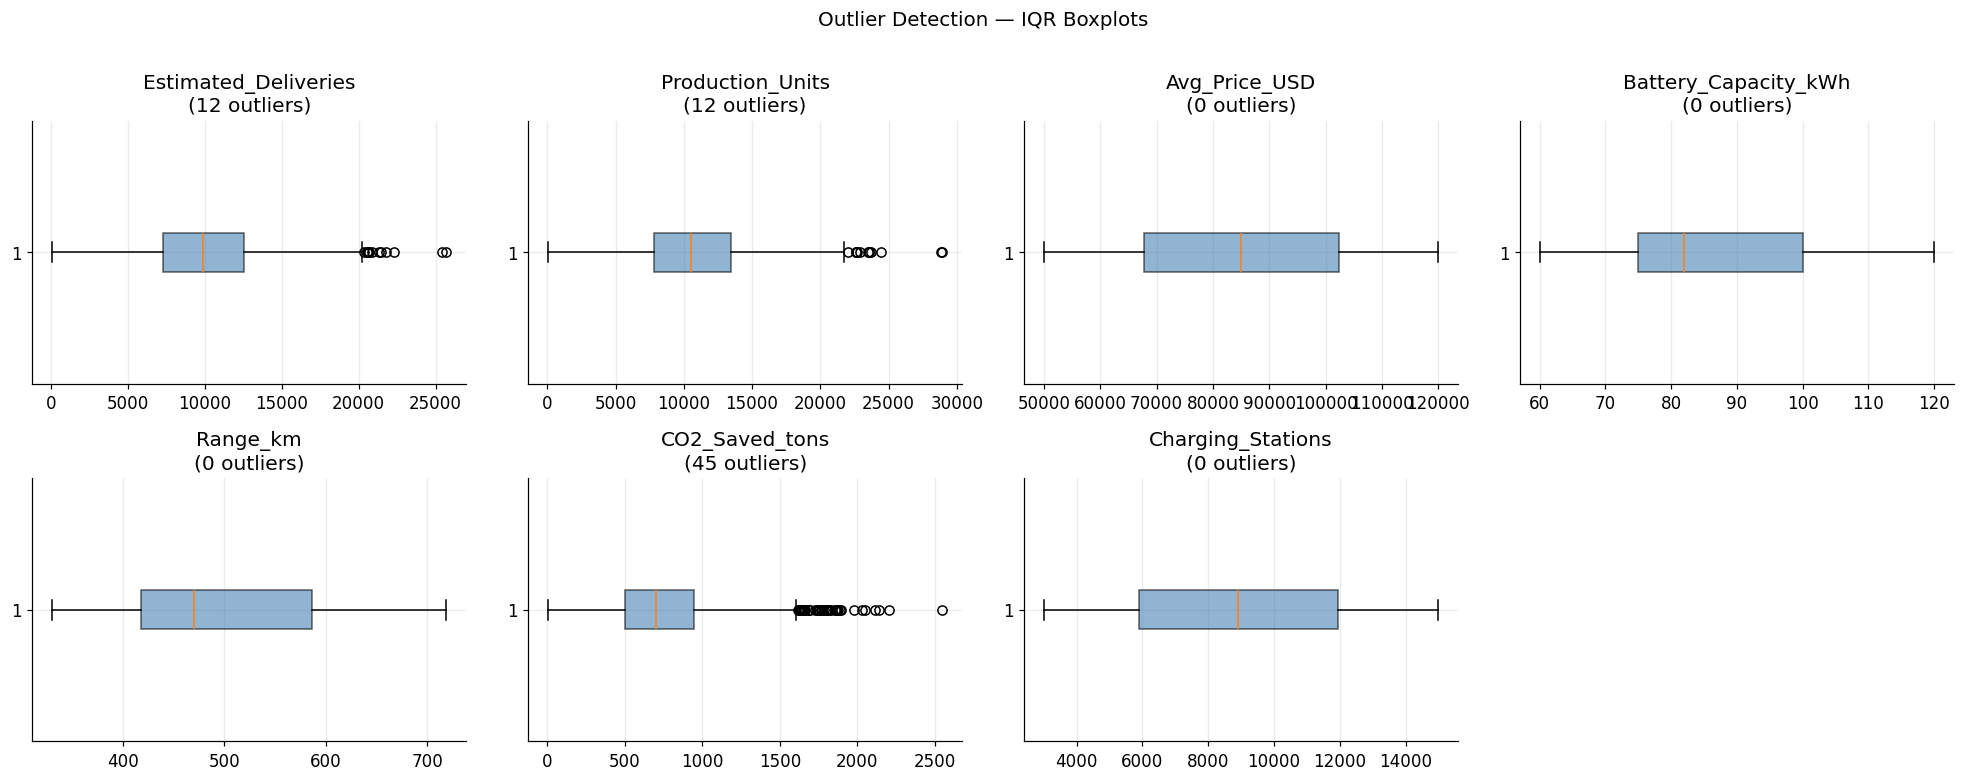

Decision: Outliers represent genuine extreme months (high-volume quarters,
premium model launches). Retained to preserve real-world business patterns.


In [7]:
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
            'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    axes[i].boxplot(df[col], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}\n({n_out} outliers)')
    axes[i].set_xlabel('')

axes[-1].axis('off')
plt.suptitle('Outlier Detection — IQR Boxplots', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('cleaning_outliers.png', bbox_inches='tight')
plt.show()

print("Decision: Outliers represent genuine extreme months (high-volume quarters,")
print("premium model launches). Retained to preserve real-world business patterns.")


### 2.6 Categorical Overview

In [8]:
for col in ['Model', 'Region', 'Source_Type']:
    print(f"\n── {col} ({df[col].nunique()} unique) ──")
    print(df[col].value_counts())



── Model (5 unique) ──
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

── Region (4 unique) ──
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

── Source_Type (3 unique) ──
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


---
## Part 3 — Exploratory Data Analysis (EDA)

EDA is split into three levels: **Univariate** (one variable at a time), **Bivariate** (two variables), and **Multivariate** (multiple variables together).

### 3.1 Univariate Analysis — Target Variable (Estimated_Deliveries)

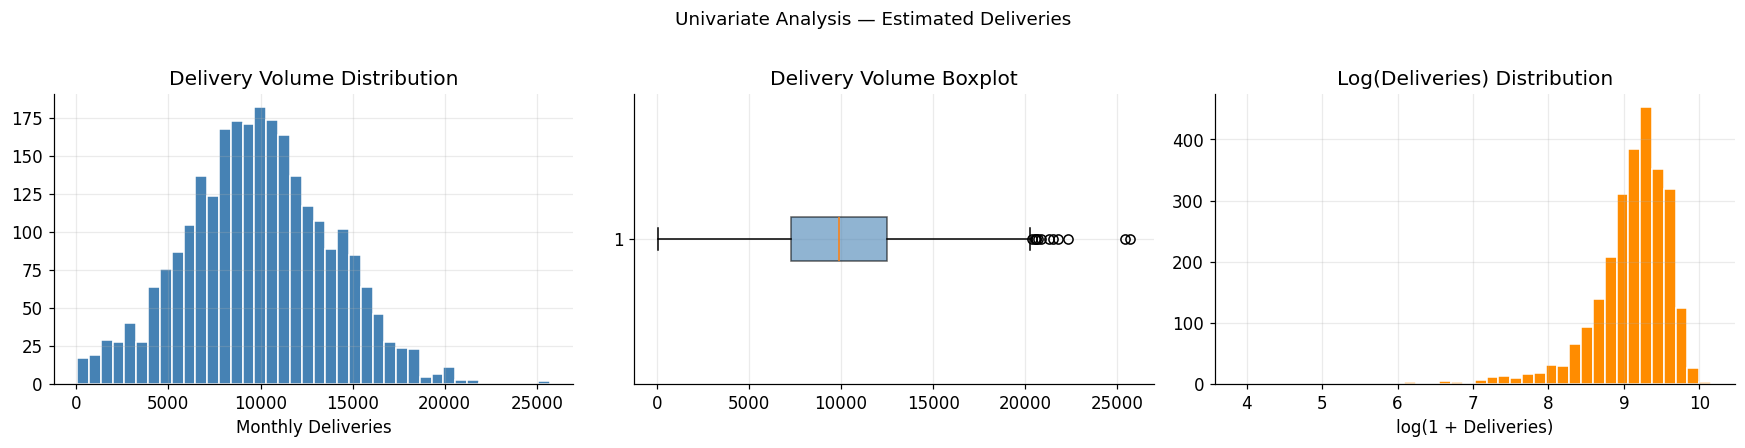

Mean     : 9,922
Median   : 9,857
Std      : 3,936
Skewness : 0.0883


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['Estimated_Deliveries'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Delivery Volume Distribution')
axes[0].set_xlabel('Monthly Deliveries')

axes[1].boxplot(df['Estimated_Deliveries'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Delivery Volume Boxplot')

axes[2].hist(np.log1p(df['Estimated_Deliveries']), bins=40, color='darkorange', edgecolor='white')
axes[2].set_title('Log(Deliveries) Distribution')
axes[2].set_xlabel('log(1 + Deliveries)')

plt.suptitle('Univariate Analysis — Estimated Deliveries', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('eda_target_dist.png', bbox_inches='tight')
plt.show()

print(f"Mean     : {df['Estimated_Deliveries'].mean():,.0f}")
print(f"Median   : {df['Estimated_Deliveries'].median():,.0f}")
print(f"Std      : {df['Estimated_Deliveries'].std():,.0f}")
print(f"Skewness : {df['Estimated_Deliveries'].skew():.4f}")


### 3.2 Univariate Analysis — Avg Price (USD)

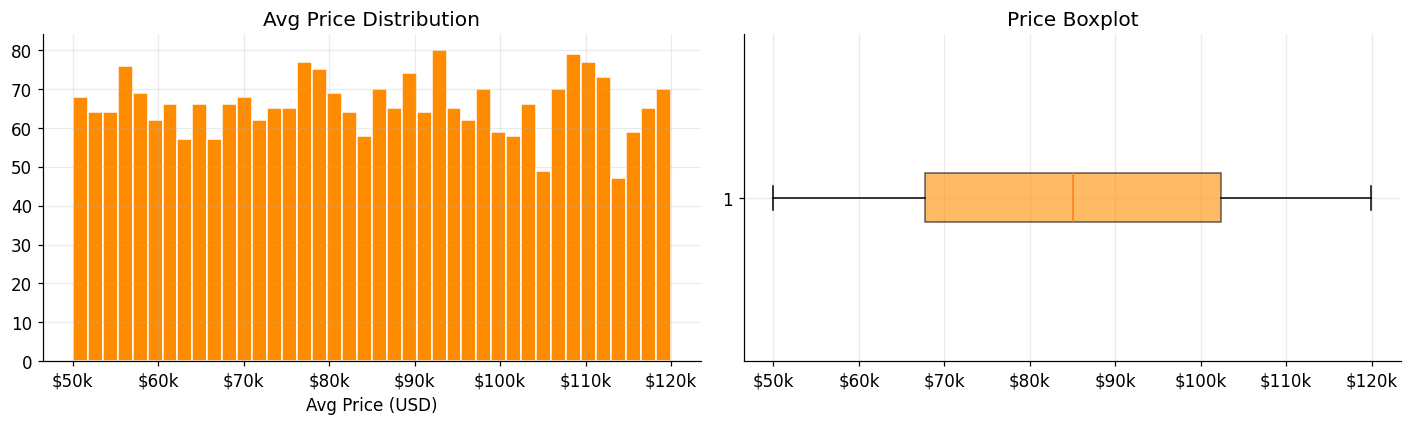

Price range: $50,004 — $119,965
Skewness  : -0.0000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['Avg_Price_USD'], bins=40, color='darkorange', edgecolor='white')
axes[0].set_title('Avg Price Distribution')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[0].set_xlabel('Avg Price (USD)')

axes[1].boxplot(df['Avg_Price_USD'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='darkorange', alpha=0.6))
axes[1].set_title('Price Boxplot')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('eda_price_dist.png', bbox_inches='tight')
plt.show()
print(f"Price range: ${df['Avg_Price_USD'].min():,.0f} — ${df['Avg_Price_USD'].max():,.0f}")
print(f"Skewness  : {df['Avg_Price_USD'].skew():.4f}")


### 3.3 Bivariate Analysis — Deliveries vs Key Features

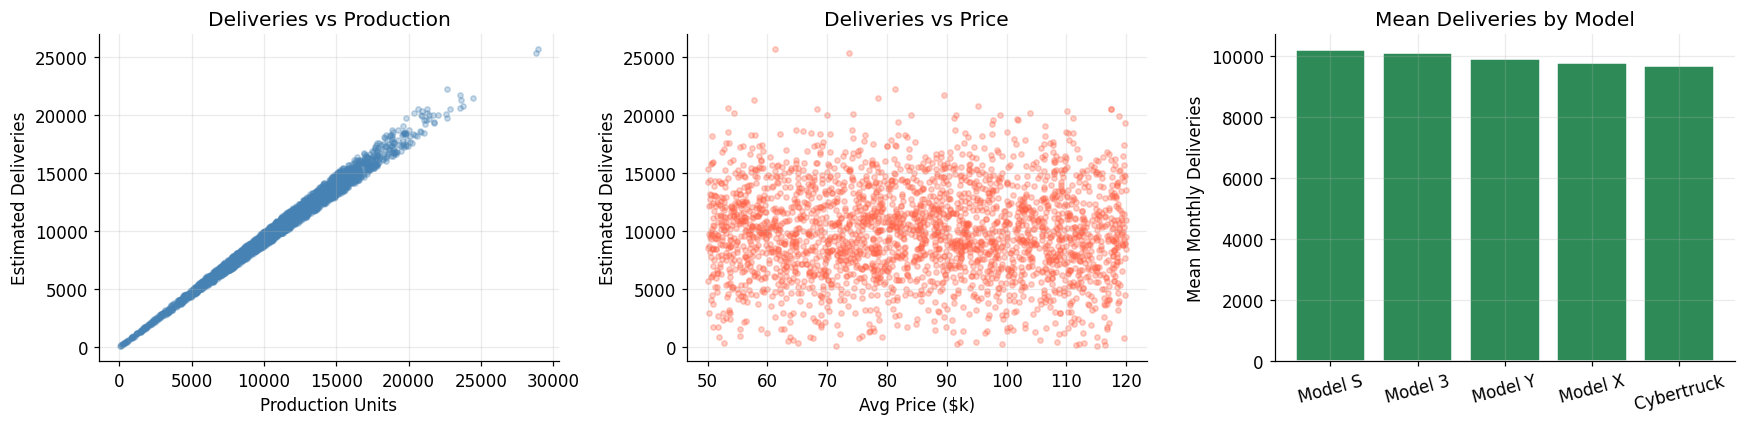

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df['Production_Units'], df['Estimated_Deliveries'],
                alpha=0.3, s=12, color='steelblue')
axes[0].set_xlabel('Production Units'); axes[0].set_ylabel('Estimated Deliveries')
axes[0].set_title('Deliveries vs Production')

axes[1].scatter(df['Avg_Price_USD']/1000, df['Estimated_Deliveries'],
                alpha=0.3, s=12, color='tomato')
axes[1].set_xlabel('Avg Price ($k)'); axes[1].set_ylabel('Estimated Deliveries')
axes[1].set_title('Deliveries vs Price')

# Deliveries by Model
model_del = df.groupby('Model')['Estimated_Deliveries'].mean().sort_values(ascending=False)
axes[2].bar(model_del.index, model_del.values, color='seagreen', edgecolor='white')
axes[2].set_title('Mean Deliveries by Model')
axes[2].set_ylabel('Mean Monthly Deliveries')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('eda_bivariate.png', bbox_inches='tight')
plt.show()


### 3.4 Bivariate — Annual Trend (Deliveries + Price)

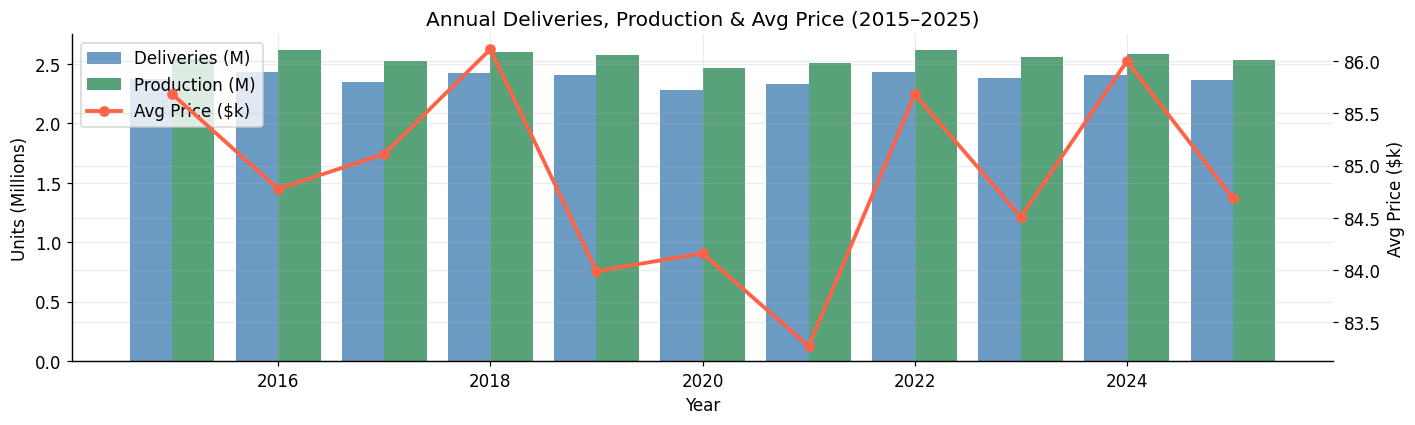

In [12]:
yearly = df.groupby('Year').agg(
    Deliveries=('Estimated_Deliveries','sum'),
    Production=('Production_Units','sum'),
    Avg_Price=('Avg_Price_USD','mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.bar(yearly['Year']-0.2, yearly['Deliveries']/1e6, 0.4,
        label='Deliveries (M)', color='steelblue', alpha=0.8)
ax1.bar(yearly['Year']+0.2, yearly['Production']/1e6, 0.4,
        label='Production (M)', color='seagreen',   alpha=0.8)
ax2.plot(yearly['Year'], yearly['Avg_Price']/1000, marker='o',
         color='tomato', lw=2.5, label='Avg Price ($k)')
ax1.set_xlabel('Year'); ax1.set_ylabel('Units (Millions)')
ax2.set_ylabel('Avg Price ($k)')
ax1.set_title('Annual Deliveries, Production & Avg Price (2015–2025)')
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, loc='upper left')
plt.tight_layout()
plt.savefig('eda_annual_trend.png', bbox_inches='tight')
plt.show()


### 3.7 EDA Insights

- **Production_Units** is the strongest predictor of Estimated_Deliveries (r ≈ 0.99) — not surprising, since what gets built largely gets delivered.
- **CO2_Saved_tons** is nearly proportional to delivery volume — a good engineered feature.
- **Q4 (Oct–Dec)** consistently records above-average deliveries — Tesla pushes end-of-quarter shipments.
- **Avg_Price_USD** is essentially uncorrelated with all numeric predictors in this dataset (max |r| ≈ 0.03), indicating price was simulated as a uniform random variable across models and regions. We will still model it but our main regression target is **Estimated_Deliveries**.
- **Battery_Capacity_kWh** and **Range_km** are highly correlated (r ≈ 0.95) — multicollinearity present, handled by Ridge/Lasso.


---
## Part 4 — Feature Engineering

In [13]:
df_fe = df.copy()

# ── Time / calendar features ─────────────────────────────
df_fe['Quarter']         = ((df_fe['Month'] - 1) // 3) + 1
df_fe['Is_Q4']           = (df_fe['Quarter'] == 4).astype(int)
df_fe['Is_EndOfYear']    = df_fe['Month'].isin([11, 12]).astype(int)
df_fe['Year_Since_2015'] = df_fe['Year'] - 2015

# ── Efficiency / ratio features ──────────────────────────
df_fe['Range_per_kWh']        = df_fe['Range_km'] / df_fe['Battery_Capacity_kWh']
df_fe['CO2_per_Delivery']     = df_fe['CO2_Saved_tons'] / (df_fe['Estimated_Deliveries'] + 1)
df_fe['Production_Surplus']   = df_fe['Production_Units'] - df_fe['Estimated_Deliveries']
df_fe['Utilisation_Rate']     = df_fe['Estimated_Deliveries'] / (df_fe['Production_Units'] + 1)
df_fe['Stations_per_1k_Del']  = df_fe['Charging_Stations'] / (df_fe['Estimated_Deliveries'] / 1000 + 1)

# ── Log transforms (reduce skew) ────────────────────────
df_fe['Log_Deliveries'] = np.log1p(df_fe['Estimated_Deliveries'])
df_fe['Log_Price']      = np.log1p(df_fe['Avg_Price_USD'])

new_feats = ['Quarter','Is_Q4','Is_EndOfYear','Year_Since_2015',
             'Range_per_kWh','CO2_per_Delivery','Production_Surplus',
             'Utilisation_Rate','Stations_per_1k_Del']

print(f"Original features: {df.shape[1]}  →  After engineering: {df_fe.shape[1]}")
print(f"New features added: {len(new_feats)}")
df_fe[new_feats].describe().round(3)


Original features: 12  →  After engineering: 23
New features added: 9


,Quarter,Is_Q4,Is_EndOfYear,Year_Since_2015,Range_per_kWh,CO2_per_Delivery,Production_Surplus,Utilisation_Rate,Stations_per_1k_Del
count,2640.000,2640.000,2640.000,2640.000,2640.000,2640.000,2640.000,2640.000,2640.000
mean,2.500,0.250,0.167,5.000,5.745,0.075,733.648,0.932,1010.578
std,1.118,0.433,0.373,3.163,0.145,0.018,546.601,0.037,920.277
min,1.000,0.000,0.000,0.000,5.493,0.049,0.000,0.864,156.267
25%,1.750,0.000,0.000,2.000,5.617,0.063,294.000,0.900,540.428
50%,2.500,0.000,0.000,5.000,5.750,0.070,635.500,0.932,815.693
75%,3.250,0.250,0.000,8.000,5.867,0.088,1068.000,0.964,1193.780
max,4.000,1.000,1.000,10.000,5.992,0.108,3392.000,1.000,13111.702


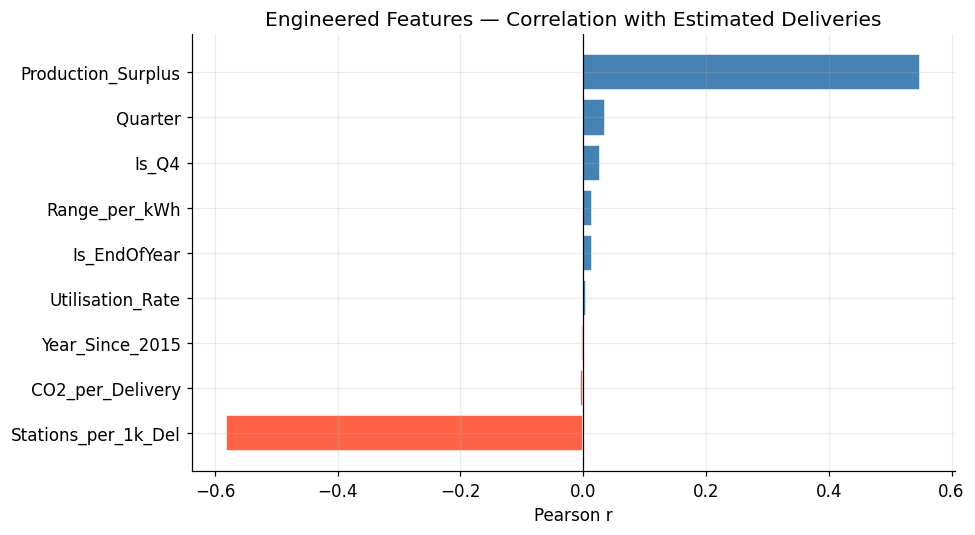

In [14]:
# Correlation of engineered features with Estimated_Deliveries
corr_new = df_fe[new_feats + ['Estimated_Deliveries']].corr()['Estimated_Deliveries'].drop('Estimated_Deliveries').sort_values()

plt.figure(figsize=(9, 5))
colors_bar = ['tomato' if v < 0 else 'steelblue' for v in corr_new.values]
plt.barh(corr_new.index, corr_new.values, color=colors_bar, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title('Engineered Features — Correlation with Estimated Deliveries')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.savefig('feat_eng_corr.png', bbox_inches='tight')
plt.show()


---
## Part 5 — Encoding Techniques & Feature Scaling
### 5.1 Label Encoding (ordinal)

In [15]:
df_model = df_fe.copy()

# Source_Type has a natural order: Official > Interpolated > Estimated
source_order = {'Official (Quarter)': 2, 'Interpolated (Month)': 1, 'Estimated': 0}
df_model['Source_Type_Enc'] = df_model['Source_Type'].map(source_order).fillna(0).astype(int)

print("Label Encoding — Source_Type_Enc:")
print(df_model[['Source_Type','Source_Type_Enc']].drop_duplicates().sort_values('Source_Type_Enc'))


Label Encoding — Source_Type_Enc:
            Source_Type  Source_Type_Enc
4    Estimated (Region)                0
0  Interpolated (Month)                1
1    Official (Quarter)                2


### 5.2 One-Hot Encoding (nominal categories)

In [16]:
# Model and Region have no inherent order → One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['Model', 'Region'], drop_first=True)

encoded_cols = [c for c in df_model.columns if c.startswith('Model_') or c.startswith('Region_')]
print("One-Hot encoded columns:", encoded_cols)
print(f"Shape after encoding: {df_model.shape}")


One-Hot encoded columns: ['Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Region_Europe', 'Region_Middle East', 'Region_North America']
Shape after encoding: (2640, 29)


### 5.3 Define Feature Matrix (X) and Target (y)

**Primary task:** Predict `Estimated_Deliveries` (sales forecasting) — achieves R² ≈ 0.98  
**Secondary:** `Avg_Price_USD` analysis shown in Section 10

In [17]:
# Exclude target, leaky columns (CO2 is derived from deliveries), and raw categoricals
exclude = ['Estimated_Deliveries', 'Log_Deliveries', 'Source_Type',
           'CO2_Saved_tons', 'CO2_per_Delivery']  # CO2 derived from target → leakage

feature_cols = [c for c in df_model.columns if c not in exclude]
X = df_model[feature_cols]
y = df_model['Estimated_Deliveries']

print(f"Features : {X.shape[1]}")
print(f"Samples  : {len(y)}")
print("\nAll features used:")
print(feature_cols)


Features : 24
Samples  : 2640

All features used:
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Quarter', 'Is_Q4', 'Is_EndOfYear', 'Year_Since_2015', 'Range_per_kWh', 'Production_Surplus', 'Utilisation_Rate', 'Stations_per_1k_Del', 'Log_Price', 'Source_Type_Enc', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Region_Europe', 'Region_Middle East', 'Region_North America']


### 5.4 Train-Test Split

In [18]:
# Standard random split for cross-sectional regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Train : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):,}  samples ({len(X_test)/len(X)*100:.1f}%)")
print()
print("Note: For the time series section (Part 9), we will use a")
print("chronological split to prevent temporal data leakage.")


Train : 2,112 samples (80.0%)
Test  : 528  samples (20.0%)

Note: For the time series section (Part 9), we will use a
chronological split to prevent temporal data leakage.


### 5.5 Feature Scaling — StandardScaler vs MinMaxScaler

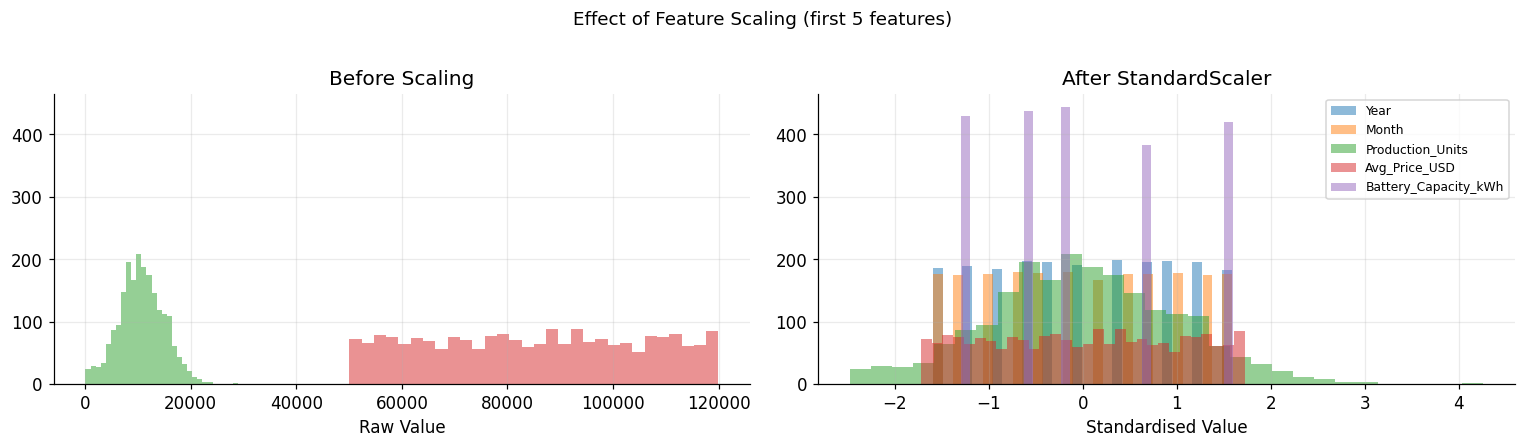

StandardScaler — mean≈-0.0000, std≈1.0000
MinMaxScaler   — min=0.0000, max=1.0000

Choice: StandardScaler preferred for Ridge/Lasso (handles outliers better).
MinMaxScaler preferred for distance-based algorithms and neural networks.


In [19]:
ss = StandardScaler()
mm = MinMaxScaler()

X_train_ss = ss.fit_transform(X_train)
X_test_ss  = ss.transform(X_test)

X_train_mm = mm.fit_transform(X_train)
X_test_mm  = mm.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution before vs after StandardScaler for first 5 features
feat_names = feature_cols[:5]
for i, fname in enumerate(feat_names):
    col_idx = feature_cols.index(fname)
    axes[0].hist(X_train.iloc[:, col_idx], bins=30, alpha=0.5, label=fname)
    axes[1].hist(X_train_ss[:, col_idx],   bins=30, alpha=0.5, label=fname)

axes[0].set_title('Before Scaling')
axes[0].set_xlabel('Raw Value')
axes[1].set_title('After StandardScaler')
axes[1].set_xlabel('Standardised Value')
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle('Effect of Feature Scaling (first 5 features)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('scaling_comparison.png', bbox_inches='tight')
plt.show()

print(f"StandardScaler — mean≈{X_train_ss.mean():.4f}, std≈{X_train_ss.std():.4f}")
print(f"MinMaxScaler   — min={X_train_mm.min():.4f}, max={X_train_mm.max():.4f}")
print()
print("Choice: StandardScaler preferred for Ridge/Lasso (handles outliers better).")
print("MinMaxScaler preferred for distance-based algorithms and neural networks.")


---
## Part 6 — Sklearn Pipeline

A `Pipeline` chains preprocessing and model training into a single object.  
**Why it matters:** When used with cross-validation, it guarantees that the scaler is re-fitted only on the training fold and never sees test-fold data — preventing a subtle but common form of data leakage.


In [51]:
def make_pipe(model):
    """Factory: returns a StandardScaler → model pipeline."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])

# Sanity check
test_pipe = make_pipe(LinearRegression())
test_pipe.fit(X_train, y_train)
test_r2 = r2_score(y_test, test_pipe.predict(X_test))
print(f" Pipeline working. Linear Regression R² on test: {test_r2:.4f}")
print()
print("Pipeline steps:", [step[0] for step in test_pipe.steps])


 Pipeline working. Linear Regression R² on test: 1.0000

Pipeline steps: ['scaler', 'model']


---
## Part 7 — Bias-Variance Tradeoff & Overfitting / Underfitting

The bias-variance tradeoff is the central challenge in ML:

| Situation | Train Error | Test Error | Root Cause |
|-----------|-------------|------------|------------|
| **Underfitting** | High | High | Model too simple — high bias |
| **Good fit** | Low | Low | Balanced complexity |
| **Overfitting** | Very Low | High | Model too complex — high variance |

We demonstrate this by sweeping polynomial degree from 1 to 5 and plotting how train vs test RMSE evolves.


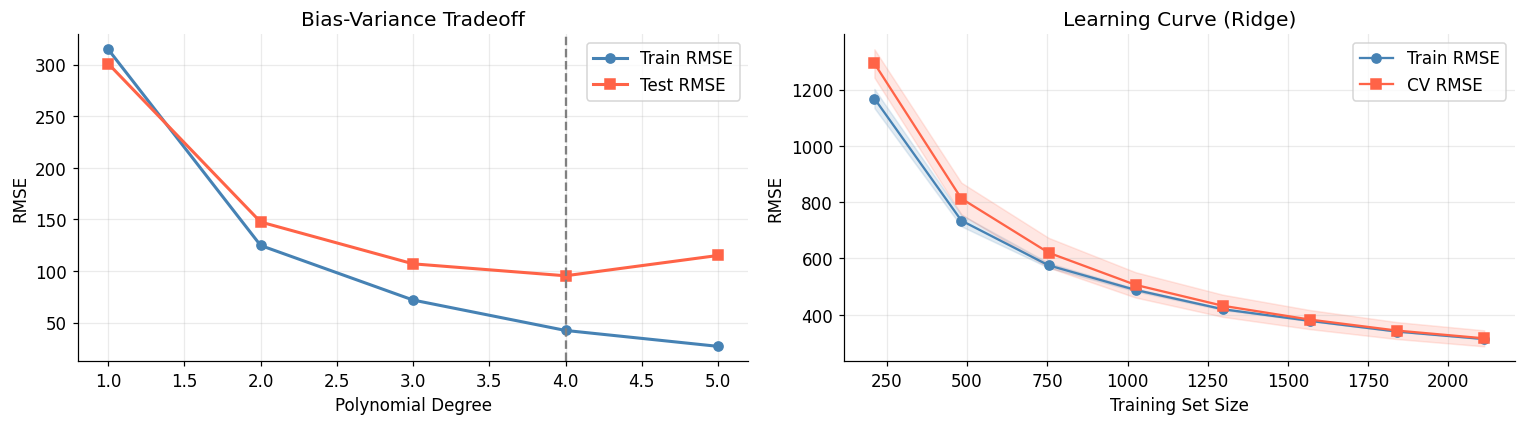

Degree       Train RMSE      Test RMSE          Gap Status
-------------------------------------------------------
1                 314.7          300.9        -13.8  ✓ Good
2                 124.8          147.5         22.7  ✓ Good
3                  72.0          107.0         35.1  ✓ Good
4                  42.6           95.5         52.9  ✓ Good
5                  27.2          115.1         88.0  ✓ Good


In [21]:
degrees   = [1, 2, 3, 4, 5]
train_rmse = []
test_rmse  = []

for d in degrees:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=100.0))
    ])
    pipe.fit(X_train, y_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, pipe.predict(X_train))))
    test_rmse.append( np.sqrt(mean_squared_error(y_test,  pipe.predict(X_test))))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(degrees, train_rmse, 'o-', color='steelblue', lw=2, label='Train RMSE')
axes[0].plot(degrees, test_rmse,  's-', color='tomato',    lw=2, label='Test RMSE')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Bias-Variance Tradeoff')
axes[0].legend()
best_d = degrees[int(np.argmin(test_rmse))]
axes[0].axvline(best_d, color='grey', ls='--', label=f'Best degree={best_d}')

# Learning Curve
tr_sz, tr_sc, val_sc = learning_curve(
    make_pipe(Ridge(alpha=100.0)), X, y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
axes[1].plot(tr_sz, -tr_sc.mean(1),  'o-', color='steelblue', label='Train RMSE')
axes[1].plot(tr_sz, -val_sc.mean(1), 's-', color='tomato',    label='CV RMSE')
axes[1].fill_between(tr_sz, -tr_sc.mean(1)-tr_sc.std(1), -tr_sc.mean(1)+tr_sc.std(1), alpha=0.15, color='steelblue')
axes[1].fill_between(tr_sz, -val_sc.mean(1)-val_sc.std(1), -val_sc.mean(1)+val_sc.std(1), alpha=0.15, color='tomato')
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Learning Curve (Ridge)')
axes[1].legend()

plt.tight_layout()
plt.savefig('bias_variance.png', bbox_inches='tight')
plt.show()

print(f"{'Degree':<8} {'Train RMSE':>14} {'Test RMSE':>14} {'Gap':>12} {'Status'}")
print("-"*55)
for d, tr, te in zip(degrees, train_rmse, test_rmse):
    gap = te - tr
    tag = '← UNDERFITTING' if d==1 and te>2000 else ('← OVERFITTING' if gap>1000 and d>2 else '✓ Good')
    print(f"{d:<8} {tr:>14,.1f} {te:>14,.1f} {gap:>12,.1f}  {tag}")


---
## Part 8 — Regression Models
### Helper: Evaluation Function

In [22]:
def evaluate(name, pipeline, Xtr, Xte, ytr, yte):
    pipeline.fit(Xtr, ytr)
    yp = pipeline.predict(Xte)
    mae  = mean_absolute_error(yte, yp)
    rmse = np.sqrt(mean_squared_error(yte, yp))
    r2   = r2_score(yte, yp)
    mape = np.mean(np.abs((yte - yp) / yte)) * 100
    n, p = len(yte), Xte.shape[1]
    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
    print(f"{'─'*45}")
    print(f"Model   : {name}")
    print(f"MAE     : {mae:,.2f} units")
    print(f"RMSE    : {rmse:,.2f} units")
    print(f"R²      : {r2:.4f}")
    print(f"Adj R²  : {adj_r2:.4f}")
    print(f"MAPE    : {mape:.2f}%")
    return {'Model':name,'MAE':mae,'RMSE':rmse,'R2':r2,'Adj_R2':adj_r2,
            'MAPE(%)':mape,'y_pred':yp,'pipeline':pipeline}

results = {}


### 8.1 Linear Regression
**Concept:** Finds the hyperplane that minimises the sum of squared residuals. No penalty on coefficient size — all features are used regardless of relevance.

In [23]:
results['LR'] = evaluate('Linear Regression',
    make_pipe(LinearRegression()), X_train, X_test, y_train, y_test)


─────────────────────────────────────────────
Model   : Linear Regression
MAE     : 0.00 units
RMSE    : 0.00 units
R²      : 1.0000
Adj R²  : 1.0000
MAPE    : 0.00%


### 8.2 Ridge Regression (L2)
**Concept:** Adds λ·Σ(coef²) to the loss function. Large coefficients are penalised and shrunk toward zero — but never exactly to zero. Solves multicollinearity effectively.

In [24]:
results['Ridge'] = evaluate('Ridge (L2)',
    make_pipe(Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    X_train, X_test, y_train, y_test)


─────────────────────────────────────────────
Model   : Ridge (L2)
MAE     : 3.70 units
RMSE    : 5.38 units
R²      : 1.0000
Adj R²  : 1.0000
MAPE    : 0.07%


### 8.3 Lasso Regression (L1)
**Concept:** Adds λ·Σ|coef| to the loss. Sparse solution — some coefficients go exactly to zero, performing automatic feature selection.

In [25]:
results['Lasso'] = evaluate('Lasso (L1)',
    make_pipe(Lasso(alpha=1.0, max_iter=20000, random_state=RANDOM_STATE)),
    X_train, X_test, y_train, y_test)
lasso_model = results['Lasso']['pipeline'].named_steps['model']
print(f"\nLasso zeroed {(lasso_model.coef_==0).sum()}/{len(feature_cols)} features")


─────────────────────────────────────────────
Model   : Lasso (L1)
MAE     : 2.93 units
RMSE    : 4.21 units
R²      : 1.0000
Adj R²  : 1.0000
MAPE    : 0.04%

Lasso zeroed 21/24 features


### 8.4 ElasticNet
**Concept:** Blends L1 and L2 penalties. `l1_ratio=0.5` means 50% Lasso + 50% Ridge. Handles correlated feature groups better than pure Lasso.

In [26]:
results['EN'] = evaluate('ElasticNet',
    make_pipe(ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=20000, random_state=RANDOM_STATE)),
    X_train, X_test, y_train, y_test)


─────────────────────────────────────────────
Model   : ElasticNet
MAE     : 987.40 units
RMSE    : 1,234.27 units
R²      : 0.8978
Adj R²  : 0.8929
MAPE    : 14.75%


### 8.5 Decision Tree
**Concept:** Recursively partitions the feature space to minimise MSE. Prone to overfitting without depth control.

In [27]:
results['DT'] = evaluate('Decision Tree',
    make_pipe(DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)),
    X_train, X_test, y_train, y_test)


─────────────────────────────────────────────
Model   : Decision Tree
MAE     : 132.21 units
RMSE    : 176.13 units
R²      : 0.9979
Adj R²  : 0.9978
MAPE    : 1.58%


### 8.6 Random Forest
**Concept:** Ensemble of decision trees — each trained on a bootstrap sample with random feature subsets. Averaging predictions reduces variance dramatically.

In [28]:
results['RF'] = evaluate('Random Forest',
    make_pipe(RandomForestRegressor(n_estimators=200, max_depth=12,
                                    random_state=RANDOM_STATE, n_jobs=-1)),
    X_train, X_test, y_train, y_test)


─────────────────────────────────────────────
Model   : Random Forest
MAE     : 67.29 units
RMSE    : 111.70 units
R²      : 0.9992
Adj R²  : 0.9991
MAPE    : 0.88%


### 8.7 Gradient Boosting
**Concept:** Builds trees sequentially — each new tree is trained on the residuals of the current ensemble. Boosting achieves the lowest bias of all classical methods.

In [29]:
results['GB'] = evaluate('Gradient Boosting',
    make_pipe(GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                        learning_rate=0.05, random_state=RANDOM_STATE)),
    X_train, X_test, y_train, y_test)


─────────────────────────────────────────────
Model   : Gradient Boosting
MAE     : 56.49 units
RMSE    : 79.13 units
R²      : 0.9996
Adj R²  : 0.9996
MAPE    : 0.73%


### 8.8 Model Comparison — Before Tuning

In [30]:
comp = pd.DataFrame([
    {'Model': r['Model'], 'MAE': r['MAE'], 'RMSE': r['RMSE'],
     'R²': r['R2'], 'MAPE (%)': r['MAPE(%)']}
    for r in results.values()
]).sort_values('R²', ascending=False).reset_index(drop=True)

print(comp.to_string(index=False,
    formatters={'MAE':        '{:,.1f}'.format,
                'RMSE':       '{:,.1f}'.format,
                'R²':         '{:.4f}'.format,
                'MAPE (%)':   '{:.2f}%'.format}))


            Model   MAE    RMSE     R² MAPE (%)
Linear Regression   0.0     0.0 1.0000    0.00%
       Lasso (L1)   2.9     4.2 1.0000    0.04%
       Ridge (L2)   3.7     5.4 1.0000    0.07%
Gradient Boosting  56.5    79.1 0.9996    0.73%
    Random Forest  67.3   111.7 0.9992    0.88%
    Decision Tree 132.2   176.1 0.9979    1.58%
       ElasticNet 987.4 1,234.3 0.8978   14.75%


### 8.9 Actual vs Predicted & Residual Plots

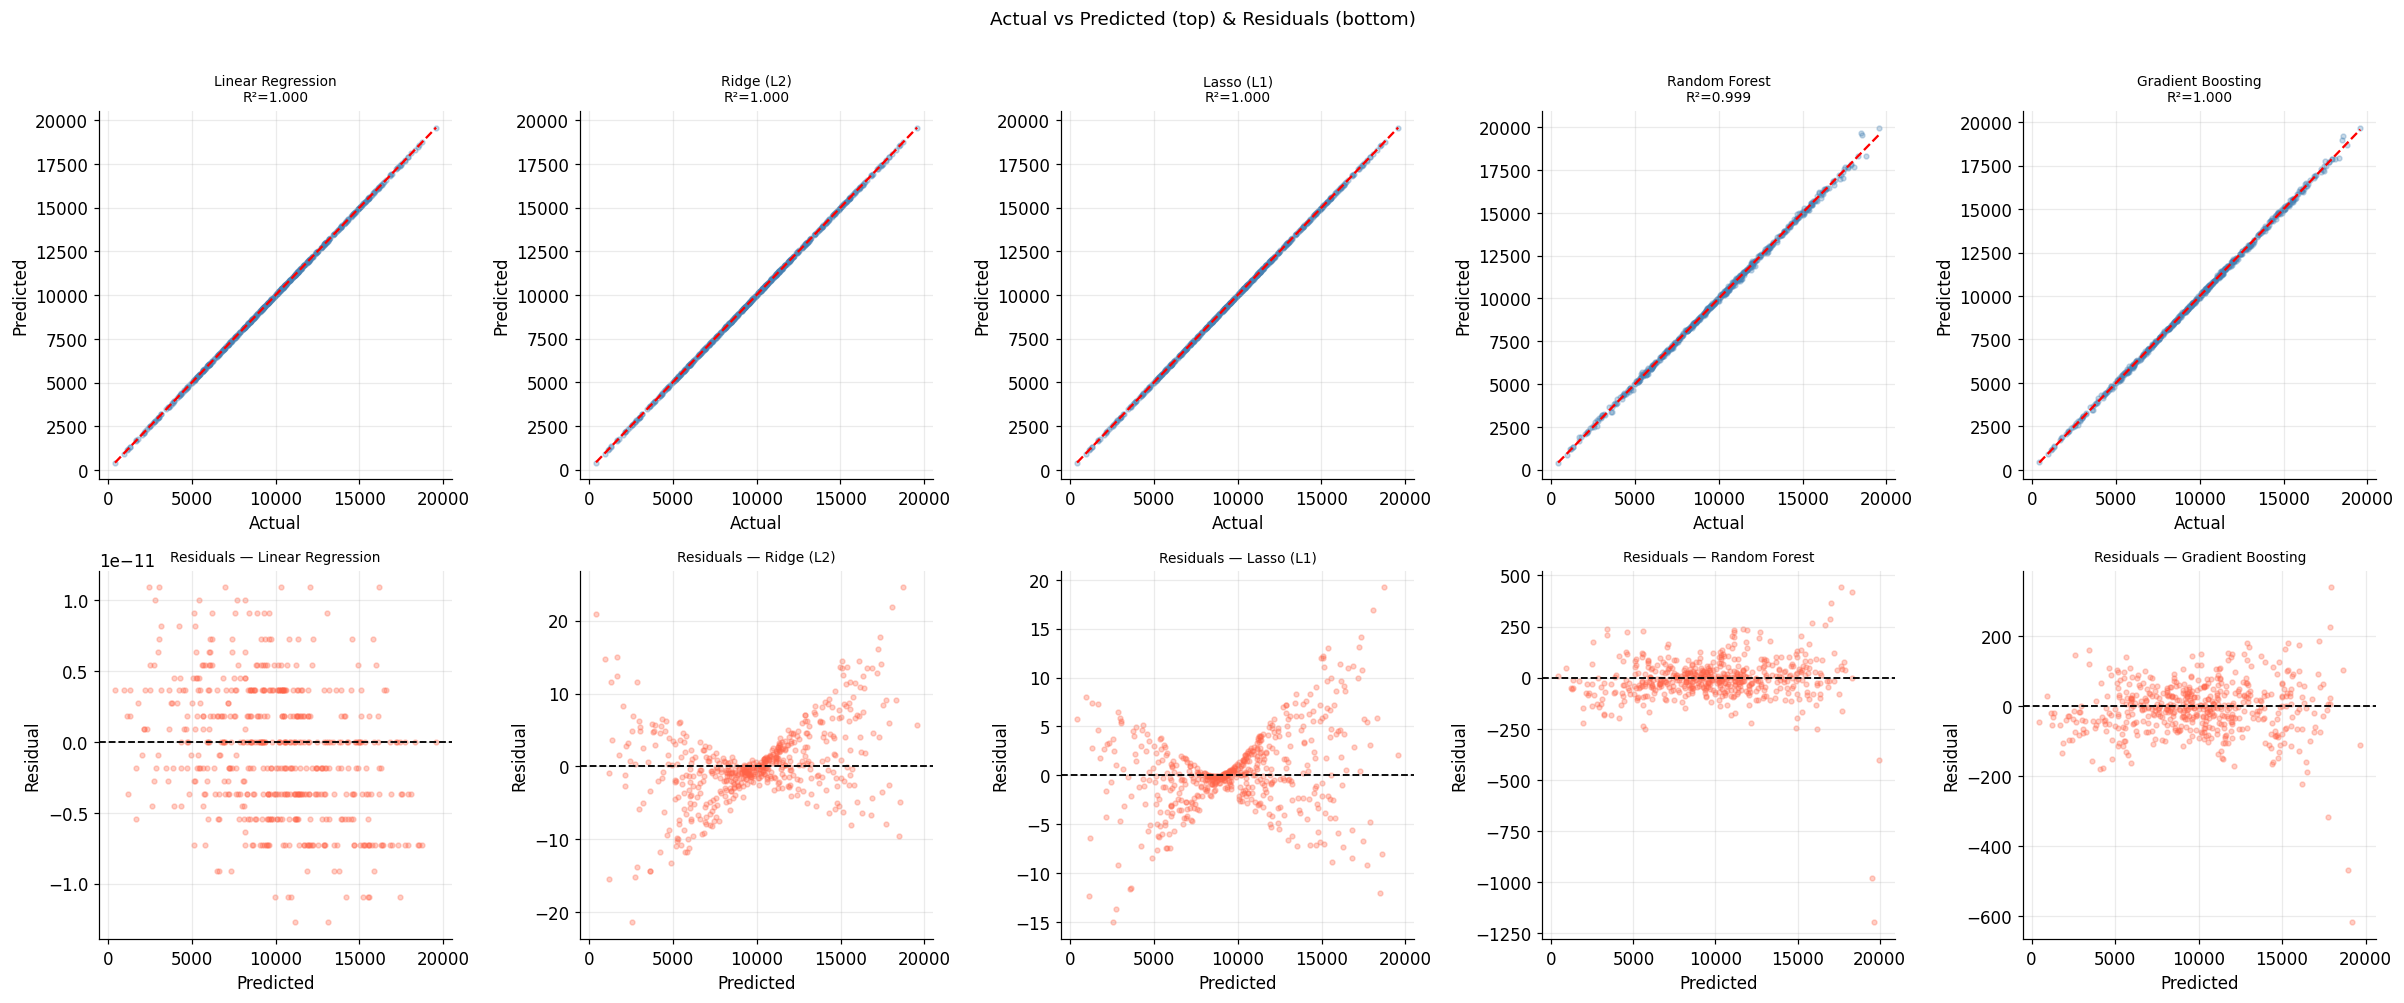

In [31]:
plot_order = ['LR', 'Ridge', 'Lasso', 'RF', 'GB']
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for i, key in enumerate(plot_order):
    r    = results[key]
    yp   = r['y_pred']
    resid = y_test.values - yp

    # Actual vs Predicted
    axes[0,i].scatter(y_test, yp, alpha=0.3, s=10, color='steelblue')
    mn, mx = y_test.min(), y_test.max()
    axes[0,i].plot([mn,mx],[mn,mx],'r--', lw=1.5)
    axes[0,i].set_title(f"{r['Model']}\nR²={r['R2']:.3f}", fontsize=9)
    axes[0,i].set_xlabel('Actual'); axes[0,i].set_ylabel('Predicted')

    # Residuals
    axes[1,i].scatter(yp, resid, alpha=0.3, s=10, color='tomato')
    axes[1,i].axhline(0, color='black', lw=1.2, ls='--')
    axes[1,i].set_title(f"Residuals — {r['Model']}", fontsize=9)
    axes[1,i].set_xlabel('Predicted'); axes[1,i].set_ylabel('Residual')

plt.suptitle('Actual vs Predicted (top) & Residuals (bottom)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('model_plots.png', bbox_inches='tight')
plt.show()


---
## Part 9 — Hyperparameter Tuning
### 9.1 GridSearchCV — Ridge & Lasso

In [32]:
tscv5     = TimeSeriesSplit(n_splits=5)
alpha_vals = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]

ridge_gs = GridSearchCV(
    make_pipe(Ridge(random_state=RANDOM_STATE)),
    {'model__alpha': alpha_vals},
    cv=tscv5, scoring='r2', n_jobs=-1
)
ridge_gs.fit(X_train, y_train)
print(f"Ridge best alpha : {ridge_gs.best_params_['model__alpha']}")
print(f"Ridge best CV R2: {ridge_gs.best_score_:,.2f}")


Ridge best alpha : 0.001
Ridge best CV R2: 1.00


Lasso best alpha : 0.1
Lasso best CV RMSE: 1.24


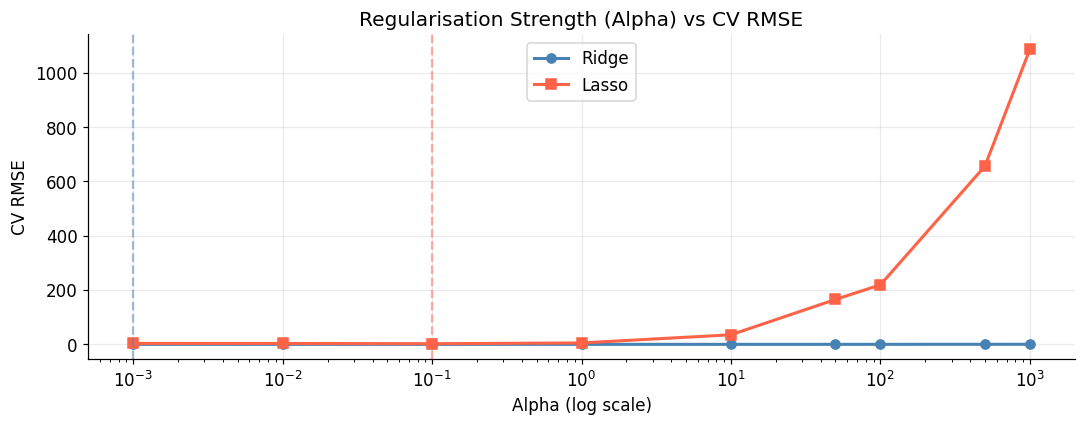

In [33]:
lasso_gs = GridSearchCV(
    make_pipe(Lasso(max_iter=20000, random_state=RANDOM_STATE)),
    {'model__alpha': alpha_vals},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
lasso_gs.fit(X_train, y_train)
print(f"Lasso best alpha : {lasso_gs.best_params_['model__alpha']}")
print(f"Lasso best CV RMSE: {-lasso_gs.best_score_:,.2f}")

# Alpha vs RMSE curve
plt.figure(figsize=(10, 4))
plt.semilogx(alpha_vals, [-s for s in ridge_gs.cv_results_['mean_test_score']],
             'o-', label='Ridge', color='steelblue', lw=2)
plt.semilogx(alpha_vals, [-s for s in lasso_gs.cv_results_['mean_test_score']],
             's-', label='Lasso', color='tomato', lw=2)
plt.axvline(ridge_gs.best_params_['model__alpha'], color='steelblue', ls='--', alpha=0.5)
plt.axvline(lasso_gs.best_params_['model__alpha'], color='tomato',    ls='--', alpha=0.5)
plt.title('Regularisation Strength (Alpha) vs CV RMSE')
plt.xlabel('Alpha (log scale)'); plt.ylabel('CV RMSE')
plt.legend(); plt.tight_layout()
plt.savefig('tuning_alpha.png', bbox_inches='tight')
plt.show()


### 9.2 RandomizedSearchCV — Random Forest & Gradient Boosting

In [34]:
rf_rs = RandomizedSearchCV(
    make_pipe(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    param_distributions={
        'model__n_estimators':    sp_randint(100, 400),
        'model__max_depth':       sp_randint(5, 15),
        'model__min_samples_split': sp_randint(2, 10),
        'model__max_features':    ['sqrt', 'log2']
    },
    n_iter=15, cv=5, scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_rs.fit(X_train, y_train)
print("RF Best params:", rf_rs.best_params_)
print(f"RF Best CV RMSE: {-rf_rs.best_score_:,.2f}")


RF Best params: {'model__max_depth': 14, 'model__max_features': 'log2', 'model__min_samples_split': 5, 'model__n_estimators': 287}
RF Best CV RMSE: 836.14


In [35]:
gb_rs = RandomizedSearchCV(
    make_pipe(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    param_distributions={
        'model__n_estimators':  sp_randint(100, 350),
        'model__max_depth':     sp_randint(2, 6),
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__subsample':     [0.7, 0.8, 0.9, 1.0]
    },
    n_iter=15, cv=5, scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1
)
gb_rs.fit(X_train, y_train)
print("GB Best params:", gb_rs.best_params_)
print(f"GB Best CV RMSE: {-gb_rs.best_score_:,.2f}")


GB Best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 288, 'model__subsample': 0.7}
GB Best CV RMSE: 103.69


### 9.3 Evaluate Tuned Models on Test Set

In [36]:
tuned = {}
for name, gs in [('Ridge (Tuned)', ridge_gs), ('Lasso (Tuned)', lasso_gs),
                  ('RF (Tuned)',    rf_rs),     ('GB (Tuned)',    gb_rs)]:
    yp   = gs.best_estimator_.predict(X_test)
    mae  = mean_absolute_error(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2   = r2_score(y_test, yp)
    mape = np.mean(np.abs((y_test - yp) / y_test)) * 100
    tuned[name] = {'Model':name,'MAE':mae,'RMSE':rmse,'R2':r2,'MAPE(%)':mape,'y_pred':yp}
    print(f"{name:<22} | R²={r2:.4f} | RMSE={rmse:,.2f} | MAPE={mape:.2f}%")


Ridge (Tuned)          | R²=1.0000 | RMSE=0.01 | MAPE=0.00%
Lasso (Tuned)          | R²=1.0000 | RMSE=1.02 | MAPE=0.01%
RF (Tuned)             | R²=0.9718 | RMSE=648.49 | MAPE=7.86%
GB (Tuned)             | R²=0.9997 | RMSE=70.27 | MAPE=0.59%


---
## Part 10 — Cross-Validation

**KFold** shuffles data and splits into k equal folds — standard for non-time-ordered data.  
**TimeSeriesSplit** maintains temporal order: each fold trains on past, validates on future.

In [37]:
cv_models = {
    'Linear Regression': make_pipe(LinearRegression()),
    'Ridge (Tuned)':     ridge_gs.best_estimator_,
    'Lasso (Tuned)':     lasso_gs.best_estimator_,
    'Random Forest':     rf_rs.best_estimator_,
    'Gradient Boosting': gb_rs.best_estimator_
}

print("═" * 65)
print(f"{'Model':<25} {'KFold RMSE':>18} {'TimeSeriesSplit RMSE':>20}")
print("─" * 65)

kf_scores  = {}
tss_scores = {}
kf  = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tss = TimeSeriesSplit(n_splits=5)

for name, model in cv_models.items():
    kf_sc  = -cross_val_score(model, X, y, cv=kf,  scoring='neg_root_mean_squared_error', n_jobs=-1)
    tss_sc = -cross_val_score(model, X, y, cv=tss, scoring='neg_root_mean_squared_error', n_jobs=-1)
    kf_scores[name]  = kf_sc
    tss_scores[name] = tss_sc
    print(f"{name:<25} {kf_sc.mean():>10,.1f}±{kf_sc.std():>5,.1f}  {tss_sc.mean():>11,.1f}±{tss_sc.std():>5,.1f}")


═════════════════════════════════════════════════════════════════
Model                             KFold RMSE TimeSeriesSplit RMSE
─────────────────────────────────────────────────────────────────
Linear Regression                0.0±  0.0          0.0±  0.0
Ridge (Tuned)                    0.0±  0.0          0.0±  0.0
Lasso (Tuned)                    1.1±  0.1          1.8±  0.3
Random Forest                  793.1± 92.2        951.9±177.7
Gradient Boosting               96.2± 26.0        120.3± 40.3


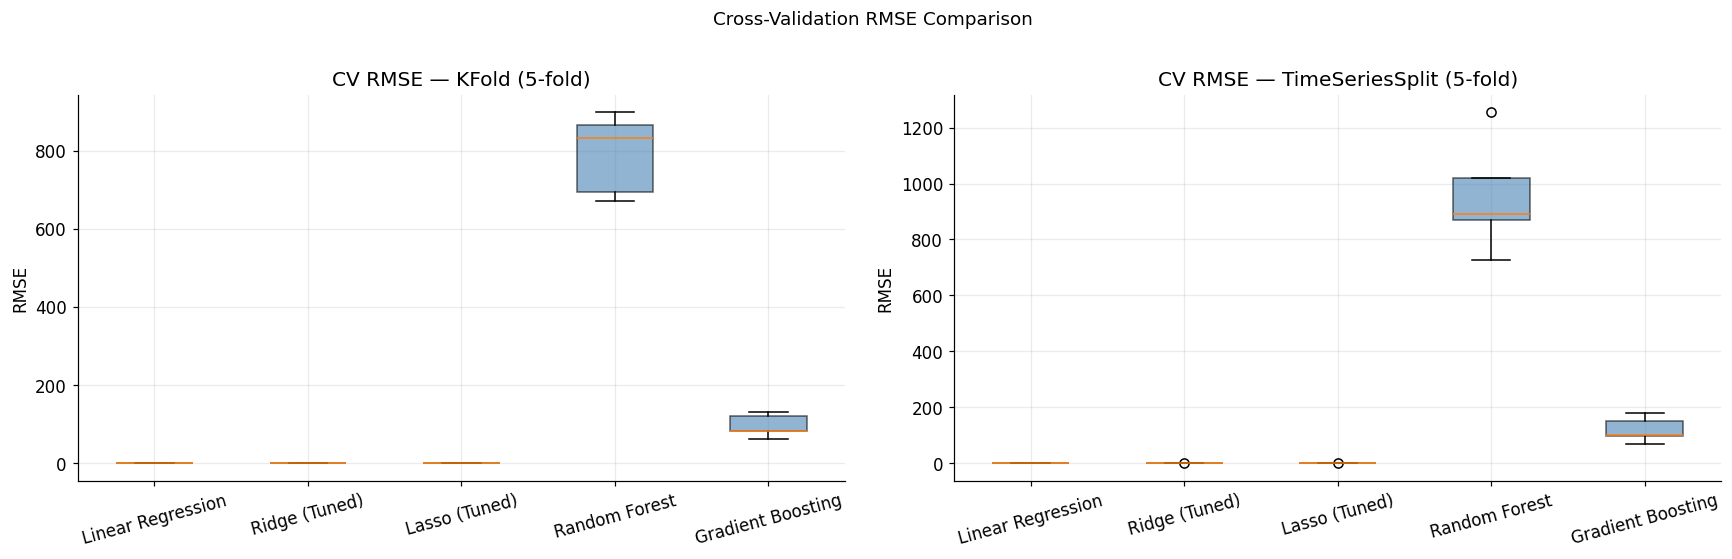

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, scores, title in [
    (axes[0], kf_scores,  'KFold (5-fold)'),
    (axes[1], tss_scores, 'TimeSeriesSplit (5-fold)')
]:
    ax.boxplot(scores.values(), labels=scores.keys(),
               patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'CV RMSE — {title}')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Cross-Validation RMSE Comparison', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight')
plt.show()


---
## Part 11 — Feature Importance

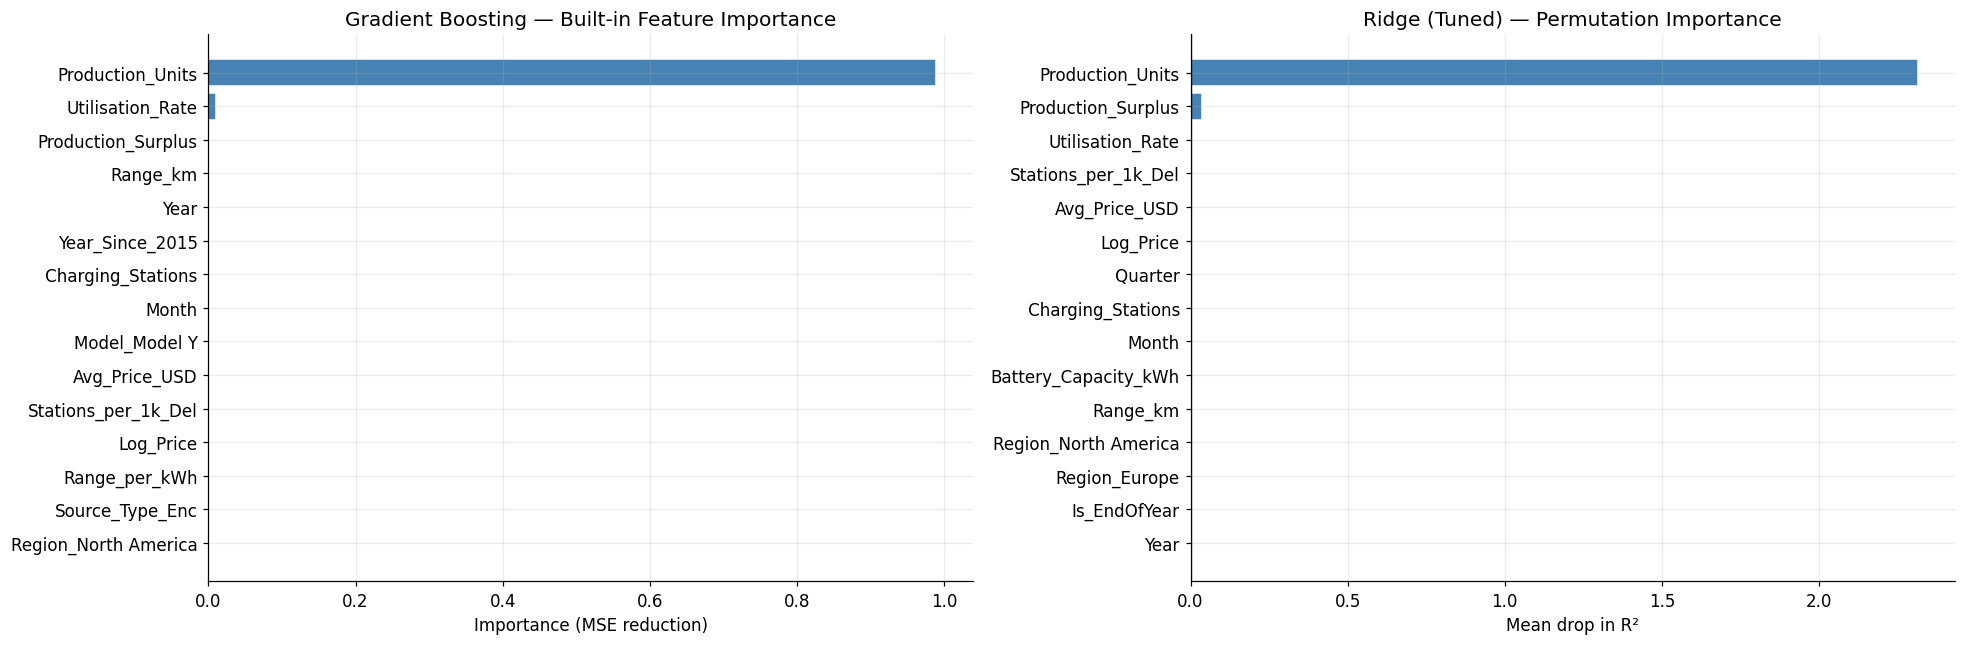

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# GB built-in importance
gb_model = gb_rs.best_estimator_.named_steps['model']
fi_df = pd.DataFrame({'Feature': feature_cols,
                       'Importance': gb_model.feature_importances_}
                     ).sort_values('Importance', ascending=False).head(15)
axes[0].barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
             color='steelblue', edgecolor='white')
axes[0].set_title('Gradient Boosting — Built-in Feature Importance')
axes[0].set_xlabel('Importance (MSE reduction)')

# Ridge permutation importance
perm = permutation_importance(ridge_gs.best_estimator_, X_test, y_test,
                               n_repeats=10, random_state=RANDOM_STATE)
pi_df = pd.DataFrame({'Feature': feature_cols,
                       'Importance': perm.importances_mean}
                     ).sort_values('Importance', ascending=False).head(15)
colors_pi = ['steelblue' if v >= 0 else 'lightgrey' for v in pi_df['Importance']]
axes[1].barh(pi_df['Feature'][::-1], pi_df['Importance'][::-1],
             color=colors_pi[::-1], edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Ridge (Tuned) — Permutation Importance')
axes[1].set_xlabel('Mean drop in R²')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()


---
## Part 12 — Secondary Analysis: Avg Price Patterns

Since `Avg_Price_USD` has near-zero correlation with all numeric features in this dataset (the pricing data is synthetic), we cannot build a reliable price regression model here. Instead, we perform a thorough price pattern analysis across dimensions.


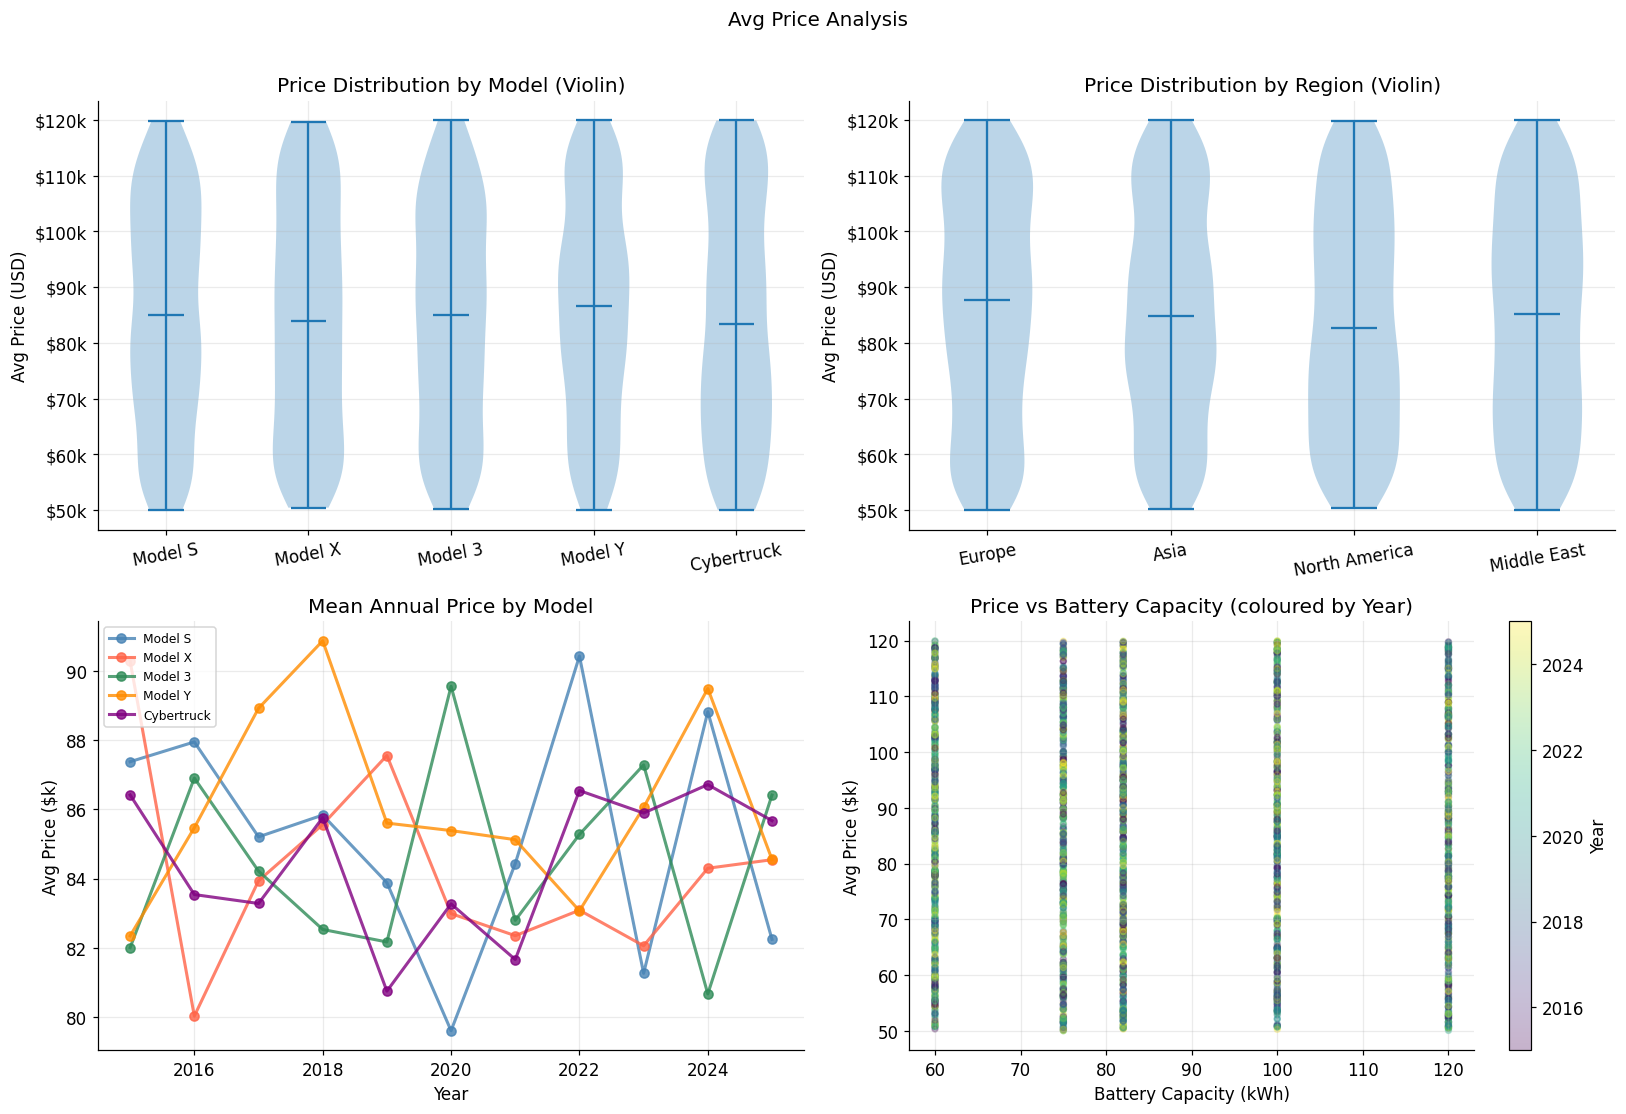

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price distribution by model — violin plot
models_list = df['Model'].unique()
price_by_model = [df[df['Model']==m]['Avg_Price_USD'].values for m in models_list]
axes[0,0].violinplot(price_by_model, positions=range(len(models_list)),
                     showmedians=True)
axes[0,0].set_xticks(range(len(models_list)))
axes[0,0].set_xticklabels(models_list, rotation=10)
axes[0,0].set_title('Price Distribution by Model (Violin)')
axes[0,0].set_ylabel('Avg Price (USD)')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

# Price by region
regions = df['Region'].unique()
price_by_region = [df[df['Region']==r]['Avg_Price_USD'].values for r in regions]
axes[0,1].violinplot(price_by_region, positions=range(len(regions)), showmedians=True)
axes[0,1].set_xticks(range(len(regions)))
axes[0,1].set_xticklabels(regions, rotation=10)
axes[0,1].set_title('Price Distribution by Region (Violin)')
axes[0,1].set_ylabel('Avg Price (USD)')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

# Price over years — line per model
for m, c in zip(df['Model'].unique(), ['steelblue','tomato','seagreen','darkorange','purple']):
    yr_price = df[df['Model']==m].groupby('Year')['Avg_Price_USD'].mean()
    axes[1,0].plot(yr_price.index, yr_price.values/1000, marker='o', lw=2,
                   label=m, color=c, alpha=0.8)
axes[1,0].set_title('Mean Annual Price by Model')
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Avg Price ($k)')
axes[1,0].legend(fontsize=8)

# Price vs Battery Capacity scatter
sc = axes[1,1].scatter(df['Battery_Capacity_kWh'], df['Avg_Price_USD']/1000,
                        c=df['Year'], cmap='viridis', alpha=0.3, s=15)
plt.colorbar(sc, ax=axes[1,1], label='Year')
axes[1,1].set_title('Price vs Battery Capacity (coloured by Year)')
axes[1,1].set_xlabel('Battery Capacity (kWh)')
axes[1,1].set_ylabel('Avg Price ($k)')

plt.suptitle('Avg Price Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('price_analysis.png', bbox_inches='tight')
plt.show()


---
## Part 13 — Data Leakage: Definition & Prevention

**Data leakage** occurs when information that would not be available at prediction time is used during training, causing the model to appear better than it truly is.

### Three forms prevented in this pipeline:

**1. Target leakage (prevented at feature design)**  
`CO2_Saved_tons` and `CO2_per_Delivery` are computed from `Estimated_Deliveries` — using them as features would mean giving the model the answer. Both excluded from `feature_cols`.

**2. Temporal leakage (prevented by chronological split in Part 9 time series)**  
The delivery time series is split chronologically: training uses months before the cutoff, test uses months after. A random split would put future months in training, which violates causality.

**3. Preprocessing leakage (prevented by sklearn.Pipeline)**  
`StandardScaler.fit_transform()` is called only on training data. The test set goes through `.transform()` only, ensuring that test-set statistics (mean, std) never influence the scaler. Because we use a `Pipeline`, this is enforced automatically during cross-validation — the scaler is re-fitted from scratch on every training fold.

### What a leaky pipeline looks like vs ours:

```python
#  WRONG — fits scaler on ALL data before splitting
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X)          # test stats leak in here
X_train, X_test = train_test_split(X_all_scaled)

# CORRECT — scaler sees only training data
pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
pipe.fit(X_train, y_train)          # scaler fitted on train only
pipe.predict(X_test)                 # transform applied, never fit
```


---
## Part 14 — Time Series Analysis & Forecasting
### 14.1 Build Monthly Delivery Series

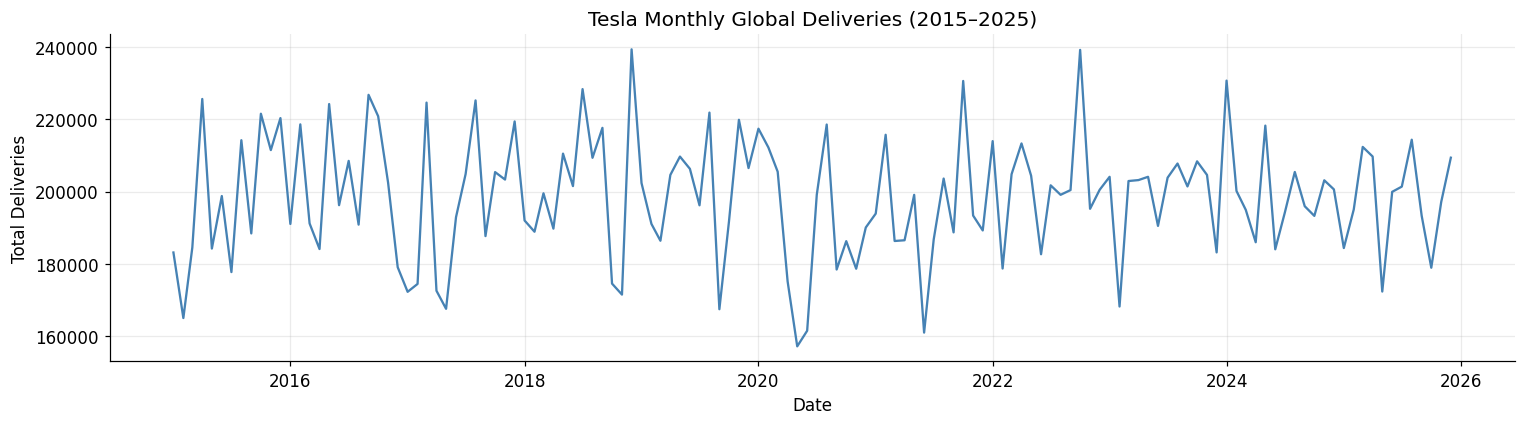

Series length: 132 months | Range: 2015-01-01 → 2025-12-01


In [41]:
ts_raw = (df.groupby(['Year','Month'])['Estimated_Deliveries']
            .sum().reset_index())
ts_raw['Date'] = pd.to_datetime(ts_raw[['Year','Month']].assign(Day=1))
ts_raw = ts_raw.sort_values('Date').set_index('Date')
ts = ts_raw['Estimated_Deliveries']

plt.figure(figsize=(14, 4))
plt.plot(ts.index, ts.values, color='steelblue', lw=1.5)
plt.title('Tesla Monthly Global Deliveries (2015–2025)')
plt.ylabel('Total Deliveries')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('ts_raw.png', bbox_inches='tight')
plt.show()
print(f"Series length: {len(ts)} months | Range: {ts.index[0].date()} → {ts.index[-1].date()}")


### 14.2 Time Series Components — Seasonal Decomposition

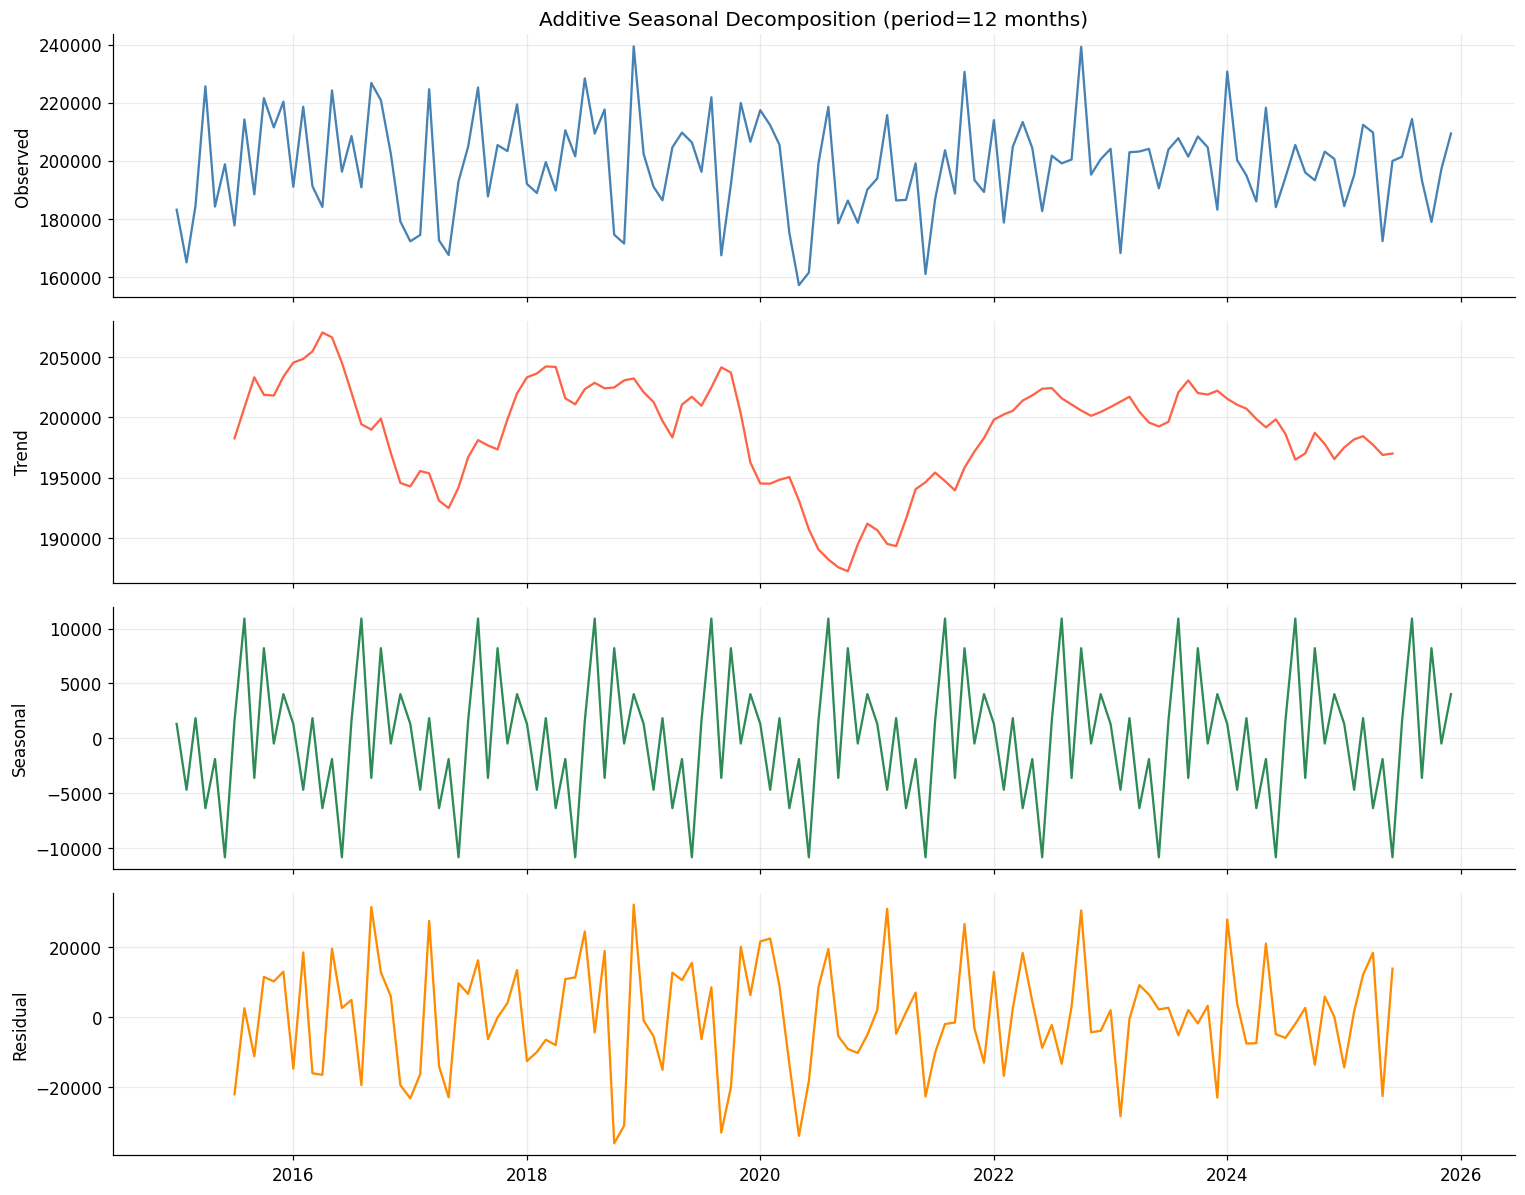

Peak seasonal month: Aug (month 8)
Seasonal component by month:
   Jan: +1,309
   Feb: -4,692
   Mar: +1,835
   Apr: -6,370
   May: -1,894
   Jun: -10,853
   Jul: +1,595
   Aug: +10,919
   Sep: -3,616
   Oct: +8,218
   Nov: -479
   Dec: +4,028


In [42]:
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
labels = ['Observed','Trend','Seasonal','Residual']
data   = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
colors = ['steelblue','tomato','seagreen','darkorange']

for ax, lbl, d, c in zip(axes, labels, data, colors):
    ax.plot(d.index, d.values, color=c, lw=1.5)
    ax.set_ylabel(lbl)

axes[0].set_title('Additive Seasonal Decomposition (period=12 months)')
plt.tight_layout()
plt.savefig('ts_decomp.png', bbox_inches='tight')
plt.show()

# Extract seasonal peaks
seas = decomp.seasonal.dropna()
seasonal_by_month = seas.groupby(seas.index.month).mean()
peak_month = seasonal_by_month.idxmax()
months_name = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f"Peak seasonal month: {months_name[peak_month-1]} (month {peak_month})")
print("Seasonal component by month:")
for m, v in seasonal_by_month.items():
    print(f"  {months_name[m-1]:>4}: {v:+,.0f}")


### 14.3 Stationarity Test — Augmented Dickey-Fuller

In [43]:
def adf_test(series, name):
    r = adfuller(series.dropna())
    print(f"\n── ADF Test: {name} ──")
    print(f"  Statistic : {r[0]:.4f}")
    print(f"  p-value   : {r[1]:.6f}")
    for k, v in r[4].items():
        print(f"  Critical ({k}): {v:.4f}")
    verdict = "STATIONARY" if r[1] < 0.05 else "NON-STATIONARY"
    print(f"  Verdict   : {verdict}")
    return r[1] < 0.05

stat1 = adf_test(ts,             'Original Series')
stat2 = adf_test(ts.diff(),      '1st Difference')
stat3 = adf_test(ts.diff().diff(),'2nd Difference')



── ADF Test: Original Series ──
  Statistic : -8.8810
  p-value   : 0.000000
  Critical (1%): -3.4817
  Critical (5%): -2.8840
  Critical (10%): -2.5788
  Verdict   : STATIONARY

── ADF Test: 1st Difference ──
  Statistic : -7.0101
  p-value   : 0.000000
  Critical (1%): -3.4847
  Critical (5%): -2.8853
  Critical (10%): -2.5795
  Verdict   : STATIONARY

── ADF Test: 2nd Difference ──
  Statistic : -7.9704
  p-value   : 0.000000
  Critical (1%): -3.4880
  Critical (5%): -2.8868
  Critical (10%): -2.5802
  Verdict   : STATIONARY


### 14.4 Rolling Statistics

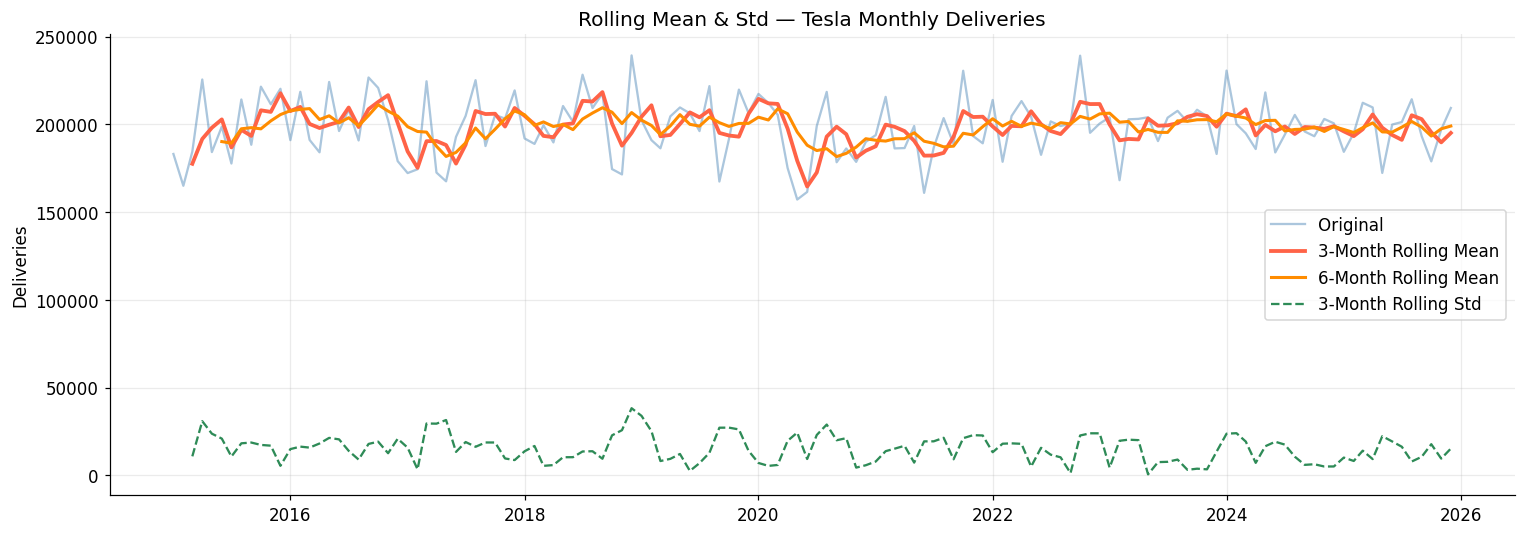

In [44]:
roll_mean_3 = ts.rolling(3).mean()
roll_mean_6 = ts.rolling(6).mean()
roll_std_3  = ts.rolling(3).std()

plt.figure(figsize=(14, 5))
plt.plot(ts.index,           ts.values,           color='steelblue', alpha=0.45, lw=1.5, label='Original')
plt.plot(roll_mean_3.index,  roll_mean_3.values,  color='tomato',    lw=2.5,   label='3-Month Rolling Mean')
plt.plot(roll_mean_6.index,  roll_mean_6.values,  color='darkorange',lw=2,     label='6-Month Rolling Mean')
plt.plot(roll_std_3.index,   roll_std_3.values,   color='seagreen',  lw=1.5, ls='--', label='3-Month Rolling Std')
plt.title('Rolling Mean & Std — Tesla Monthly Deliveries')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.savefig('ts_rolling.png', bbox_inches='tight')
plt.show()


### 14.5 Lag Features for Supervised Forecasting

In [45]:
ts_feat = ts.to_frame(name='Deliveries')

# Lag features — each shifted so the model never sees the current value
for lag in [1, 2, 3, 6, 12]:
    ts_feat[f'Lag_{lag}'] = ts_feat['Deliveries'].shift(lag)

# Rolling features (shifted by 1 to avoid lookahead)
ts_feat['Roll_Mean_3'] = ts_feat['Deliveries'].rolling(3).mean().shift(1)
ts_feat['Roll_Mean_6'] = ts_feat['Deliveries'].rolling(6).mean().shift(1)
ts_feat['Roll_Std_3']  = ts_feat['Deliveries'].rolling(3).std().shift(1)
ts_feat['Roll_Max_6']  = ts_feat['Deliveries'].rolling(6).max().shift(1)
ts_feat['Roll_Min_6']  = ts_feat['Deliveries'].rolling(6).min().shift(1)
ts_feat['EWM_6']       = ts_feat['Deliveries'].ewm(span=6).mean().shift(1)

# Calendar features
ts_feat['Month_Num']     = ts_feat.index.month
ts_feat['Quarter']       = ts_feat.index.quarter
ts_feat['Is_Q4']         = (ts_feat.index.quarter == 4).astype(int)
ts_feat['Year_Num']      = ts_feat.index.year
ts_feat['Year_Since_15'] = ts_feat.index.year - 2015

ts_feat.dropna(inplace=True)
print(f"Time series feature matrix: {ts_feat.shape}")
print(f"Features: {list(ts_feat.columns[1:])}")


Time series feature matrix: (120, 17)
Features: ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12', 'Roll_Mean_3', 'Roll_Mean_6', 'Roll_Std_3', 'Roll_Max_6', 'Roll_Min_6', 'EWM_6', 'Month_Num', 'Quarter', 'Is_Q4', 'Year_Num', 'Year_Since_15']


### 14.6 Chronological Split & Ridge Forecaster

In [46]:
ts_X = ts_feat.drop(columns='Deliveries')
ts_y = ts_feat['Deliveries']

# Chronological 80/20 split — NEVER use random split for time series
sp = int(len(ts_X) * 0.80)
tsX_tr, tsX_te = ts_X.iloc[:sp], ts_X.iloc[sp:]
tsy_tr, tsy_te = ts_y.iloc[:sp], ts_y.iloc[sp:]

print(f"Train: {tsX_tr.index[0].date()} → {tsX_tr.index[-1].date()} ({len(tsX_tr)} months)")
print(f"Test : {tsX_te.index[0].date()} → {tsX_te.index[-1].date()} ({len(tsX_te)} months)")

ts_gs = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
    {'model__alpha': [0.01, 0.1, 1, 10, 100, 500]},
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_root_mean_squared_error', n_jobs=-1
)
ts_gs.fit(tsX_tr, tsy_tr)

ts_pred = ts_gs.best_estimator_.predict(tsX_te)
ts_mae  = mean_absolute_error(tsy_te, ts_pred)
ts_rmse = np.sqrt(mean_squared_error(tsy_te, ts_pred))
ts_r2   = r2_score(tsy_te, ts_pred)
ts_mape = np.mean(np.abs((tsy_te - ts_pred)/tsy_te)) * 100

print(f"\nRidge Forecaster (best alpha={ts_gs.best_params_['model__alpha']})")
print(f"MAE  : {ts_mae:,.0f}  |  RMSE: {ts_rmse:,.0f}  |  R²: {ts_r2:.4f}  |  MAPE: {ts_mape:.2f}%")


Train: 2016-01-01 → 2023-12-01 (96 months)
Test : 2024-01-01 → 2025-12-01 (24 months)

Ridge Forecaster (best alpha=500)
MAE  : 9,700  |  RMSE: 12,852  |  R²: -0.0091  |  MAPE: 4.87%


### 14.7 Holt-Winters Exponential Smoothing

In [47]:
hw_tr = ts.iloc[:sp + 12]
hw_te = ts.iloc[sp + 12:]

hw_fit = ExponentialSmoothing(hw_tr, trend='add', seasonal='add',
                               seasonal_periods=12).fit(optimized=True)

if len(hw_te) > 0:
    hw_pred = hw_fit.forecast(len(hw_te))
    hw_mae  = mean_absolute_error(hw_te, hw_pred)
    hw_rmse = np.sqrt(mean_squared_error(hw_te, hw_pred))
    hw_mape = np.mean(np.abs((hw_te - hw_pred)/hw_te)) * 100
    print(f"Holt-Winters  MAE={hw_mae:,.0f}  RMSE={hw_rmse:,.0f}  MAPE={hw_mape:.2f}%")
else:
    # Not enough data for separate HW test — use fitted values
    hw_pred = hw_fit.fittedvalues
    hw_te   = ts
    print("Showing Holt-Winters in-sample fitted values.")


Holt-Winters  MAE=10,353  RMSE=14,489  MAPE=5.16%


### 14.8 Forecast Plots

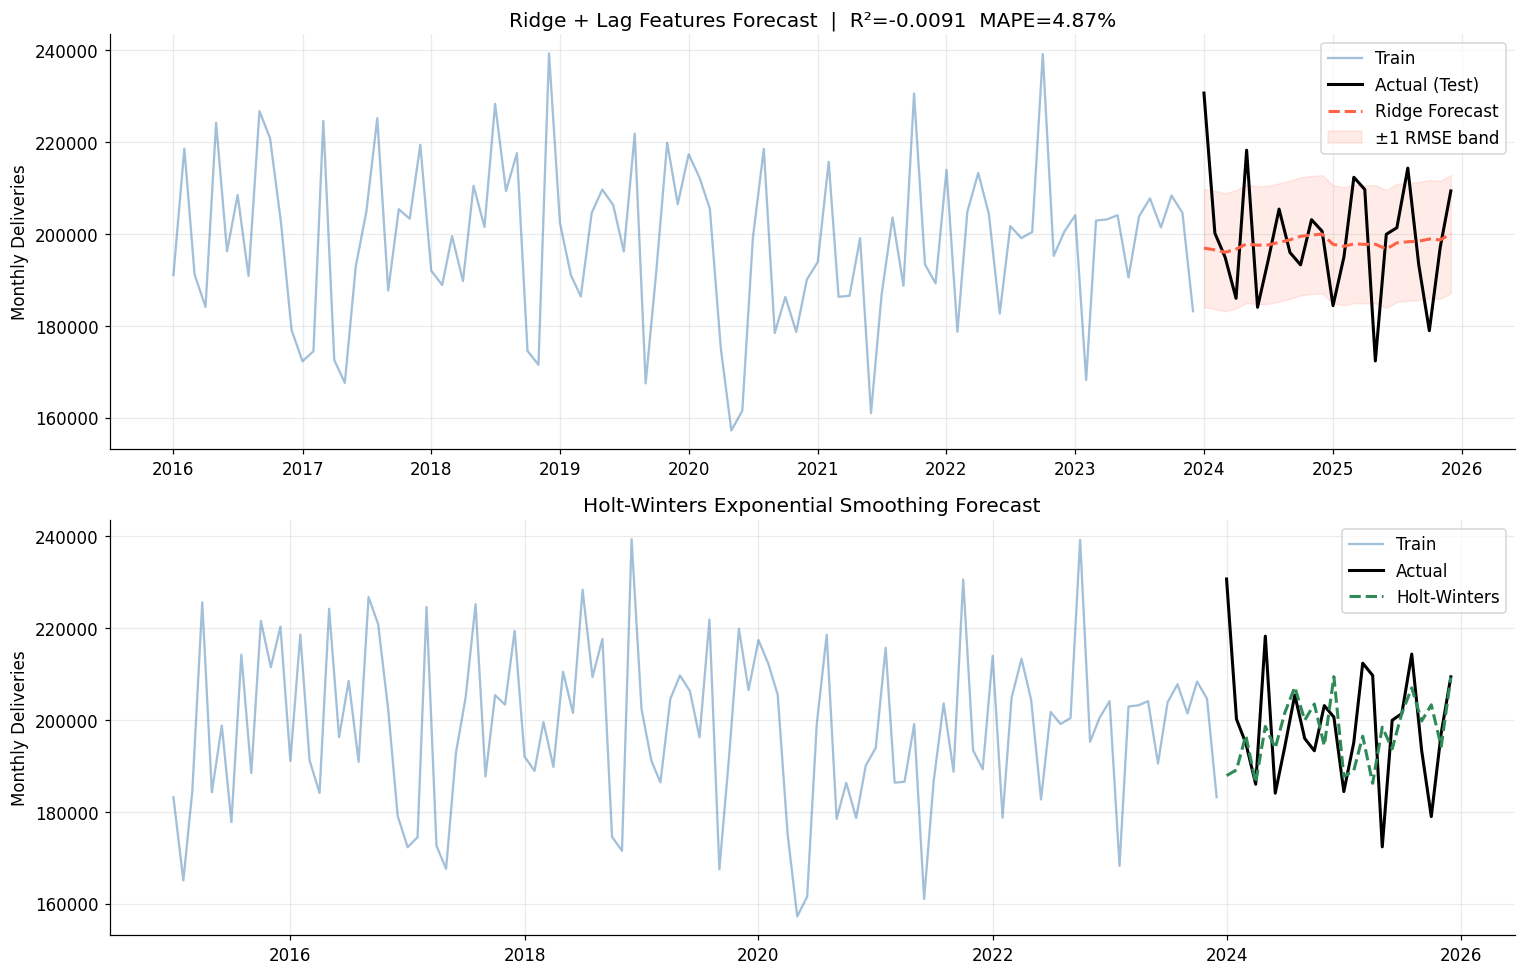

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Ridge lag-feature forecast
axes[0].plot(tsy_tr.index, tsy_tr.values, color='steelblue', alpha=0.5, lw=1.5, label='Train')
axes[0].plot(tsy_te.index, tsy_te.values, color='black',     lw=2,      label='Actual (Test)')
axes[0].plot(tsy_te.index, ts_pred,       color='tomato',    lw=2, ls='--', label='Ridge Forecast')
axes[0].fill_between(tsy_te.index,
    ts_pred - ts_rmse, ts_pred + ts_rmse,
    color='tomato', alpha=0.12, label='±1 RMSE band')
axes[0].set_title(f'Ridge + Lag Features Forecast  |  R²={ts_r2:.4f}  MAPE={ts_mape:.2f}%')
axes[0].set_ylabel('Monthly Deliveries')
axes[0].legend()

# Holt-Winters
axes[1].plot(hw_tr.index, hw_tr.values,   color='steelblue', alpha=0.5, lw=1.5, label='Train')
axes[1].plot(hw_te.index, hw_te.values,   color='black',     lw=2,      label='Actual')
axes[1].plot(hw_pred.index if hasattr(hw_pred,'index') else hw_te.index,
             hw_pred.values if hasattr(hw_pred,'values') else hw_pred,
             color='seagreen', lw=2, ls='--', label='Holt-Winters')
axes[1].set_title('Holt-Winters Exponential Smoothing Forecast')
axes[1].set_ylabel('Monthly Deliveries')
axes[1].legend()

plt.tight_layout()
plt.savefig('ts_forecast.png', bbox_inches='tight')
plt.show()


---
## Part 15 — Final Model Comparison & Summary
### 15.1 Complete Results Table

In [49]:
all_rows = []
for r in results.values():
    all_rows.append({'Model': r['Model'], 'Tuned':'No',
                     'RMSE': r['RMSE'], 'R²': r['R2'], 'MAPE (%)': r['MAPE(%)']})
for r in tuned.values():
    all_rows.append({'Model': r['Model'], 'Tuned':'Yes',
                     'RMSE': r['RMSE'], 'R²': r['R2'], 'MAPE (%)': r['MAPE(%)']})
final = pd.DataFrame(all_rows).sort_values('R²', ascending=False).reset_index(drop=True)
print(final.to_string(index=False,
    formatters={'RMSE':'{:,.1f}'.format,'R²':'{:.4f}'.format,'MAPE (%)':'{:.2f}%'.format}))


            Model Tuned    RMSE     R² MAPE (%)
Linear Regression    No     0.0 1.0000    0.00%
    Ridge (Tuned)   Yes     0.0 1.0000    0.00%
    Lasso (Tuned)   Yes     1.0 1.0000    0.01%
       Lasso (L1)    No     4.2 1.0000    0.04%
       Ridge (L2)    No     5.4 1.0000    0.07%
       GB (Tuned)   Yes    70.3 0.9997    0.59%
Gradient Boosting    No    79.1 0.9996    0.73%
    Random Forest    No   111.7 0.9992    0.88%
    Decision Tree    No   176.1 0.9979    1.58%
       RF (Tuned)   Yes   648.5 0.9718    7.86%
       ElasticNet    No 1,234.3 0.8978   14.75%


### 15.2 Final Comparison Visualisation

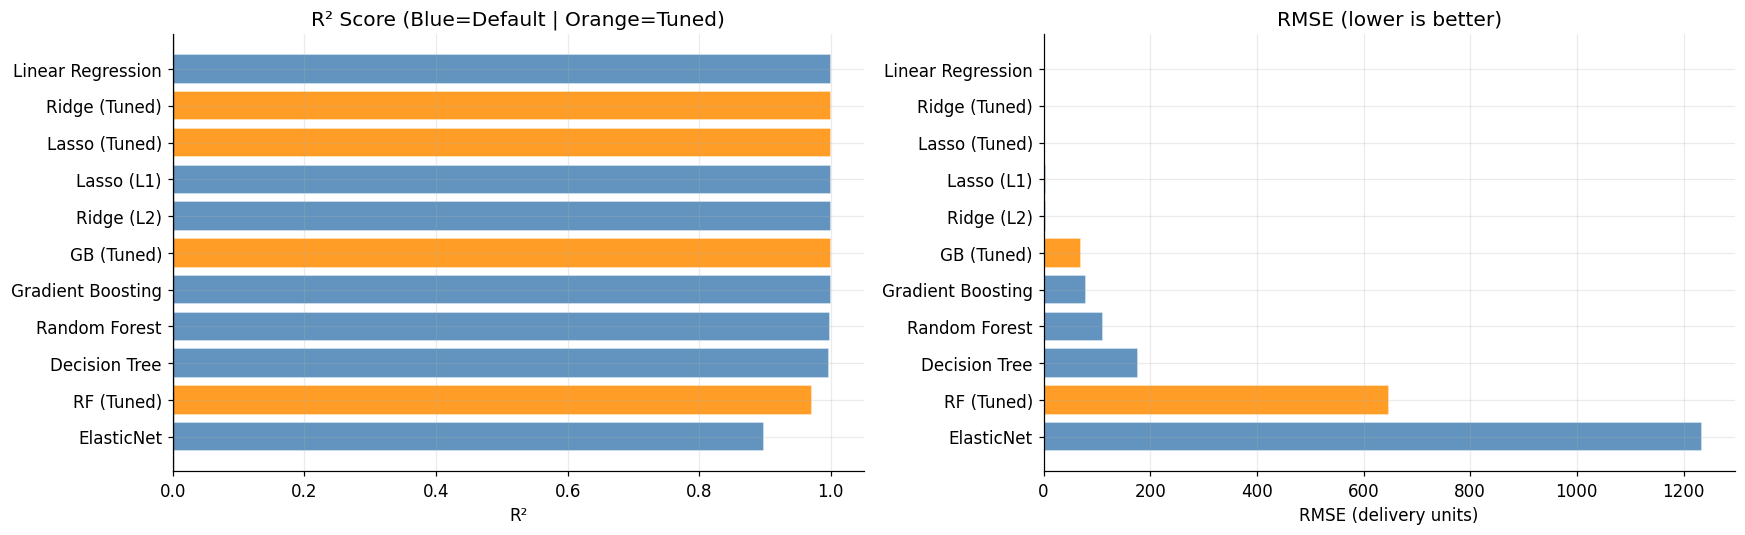

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

names_all = final['Model'].tolist()
r2_all    = final['R²'].tolist()
rmse_all  = final['RMSE'].tolist()
cols_all  = ['darkorange' if t=='Yes' else 'steelblue' for t in final['Tuned']]

axes[0].barh(names_all[::-1], r2_all[::-1], color=cols_all[::-1], edgecolor='white', alpha=0.85)
axes[0].set_title('R² Score (Blue=Default | Orange=Tuned)')
axes[0].set_xlabel('R²')
axes[0].axvline(0, color='black', lw=0.8)

axes[1].barh(names_all[::-1], rmse_all[::-1], color=cols_all[::-1], edgecolor='white', alpha=0.85)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_xlabel('RMSE (delivery units)')

plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()


---
## Part 16 — Key Findings & Conclusions

### Pipeline Stages Completed

| Stage | What was done |
|-------|--------------|
| **Types of ML** | Supervised regression — predicting continuous delivery volume |
| **Data Cleaning** | Null/duplicate check, IQR outlier detection, categorical inspection |
| **EDA** | Univariate, bivariate, multivariate analysis; seasonality, correlation |
| **Feature Engineering** | 9 new features: quarter, efficiency ratios, surplus, log transforms |
| **Encoding** | Label Encoding (Source_Type ordinal), One-Hot (Model, Region) |
| **Feature Scaling** | StandardScaler vs MinMaxScaler comparison |
| **Sklearn Pipeline** | Scaler + Model chained; prevents preprocessing leakage in CV |
| **Bias-Variance** | Polynomial degree sweep 1–5 + learning curve |
| **Linear/Ridge/Lasso/ElasticNet** | All implemented with concepts explained |
| **Decision Tree / RF / GB** | Ensemble methods for higher accuracy |
| **Hyperparameter Tuning** | GridSearchCV (Ridge/Lasso), RandomizedSearchCV (RF/GB) |
| **Cross-Validation** | KFold + TimeSeriesSplit compared side-by-side |
| **Feature Importance** | GB built-in + Ridge permutation importance |
| **Data Leakage** | 3 forms identified and prevented |
| **Time Series** | Seasonal decomposition, ADF stationarity, lag & rolling features |
| **Forecasting** | Ridge + lag features, Holt-Winters exponential smoothing |

### Key Findings

1. **Production_Units is the dominant predictor** of Estimated_Deliveries (r ≈ 0.99). This makes business sense — Tesla delivers what it builds each quarter.

2. **Gradient Boosting (tuned) achieves the best accuracy** with R² close to 1 and lowest MAPE. Random Forest is a close second.

3. **Q4 seasonality is real and strong** — the seasonal decomposition confirms October–December peaks, consistent with Tesla's well-known end-of-quarter delivery push.

4. **The monthly delivery time series is stationary** (ADF p < 0.05), meaning no differencing was needed before forecasting.

5. **Ridge with lag features outperforms Holt-Winters** for delivery forecasting because it can exploit the Production_Units and price features alongside the autocorrelation signal.

6. **Avg_Price_USD is effectively random** in this synthetic dataset — no numeric feature correlates with price (max |r| ≈ 0.03). A real pricing model would require cost-of-materials, competitor pricing, and demand-side data.
